Comparing my NorESM2.3 run with Dirk's KeyClim run before making simulations of volcanic eruptions. 

In [98]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.colors as colors
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob

In [2]:
from check_time import extract_vars

In [3]:
"""# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client"""

'# dask\nimport dask\nimport dask.array as da\nimport distributed\nfrom dask.distributed import Client\n\nclient = Client()\nclient'

In [4]:
"""
path_atm_KeyClim = "/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/atm/hist"
glob_files = sorted(glob(f"{path_atm_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.19[7-9]*.nc"))
#glob_files = glob_files.append(sorted(glob(f"{path_atm_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.20*.nc")))
dr = pd.date_range(start="1975-01-01", end="2014-12-31", freq="MS")
dr = dr.strftime("%Y-%m").tolist()
dr
paths=[None]*len(dr)
for i, d in enumerate(dr):
    paths[i] = path_atm_KeyClim + f"/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.{d}.nc"

paths[0]
"""

'\npath_atm_KeyClim = "/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/atm/hist"\nglob_files = sorted(glob(f"{path_atm_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.19[7-9]*.nc"))\n#glob_files = glob_files.append(sorted(glob(f"{path_atm_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.20*.nc")))\ndr = pd.date_range(start="1975-01-01", end="2014-12-31", freq="MS")\ndr = dr.strftime("%Y-%m").tolist()\ndr\npaths=[None]*len(dr)\nfor i, d in enumerate(dr):\n    paths[i] = path_atm_KeyClim + f"/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.{d}.nc"\n\npaths[0]\n'

In [5]:
# Vars I have extracted already from KeyCLIM data:
#          "TREFHT", "AODVVOLC", "AOD_VIS", "SO2",
#          "TS", "U", "Z3", "O3", "FLNT", "FSNT", 
#          "FSNTOA", "DAYFOC", "OCNFRAC", "cb_O3", 
#          "O3_SRF", "PRECC", "PRECL", "OH", "SO2",
#          "SO2_SRF"

# extracted from 1975-2014 long run:
#          "H2SO4", "mmr_SULFATE", "SO2", "TROP_P",
#          "TREFHT", "AODVVOLC", "AOD_VIS",
#          "TS", "U", "Z3", "O3", "FLNT", "FSNT", 
#          "FSNTOA", "DAYFOC", "OCNFRAC", "cb_O3",   
#          "O3_SRF", "PRECC", "PRECL", "OH",
#          "SO2_SRF", "T", "REFF_AERO" "FLNS", "FSNS"

"""
extract_vars(fld="/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist",
             vars=["FLNS", "FSNS"],  
             ystart=1975,
             yend=2014,
             outfld="/nird/datapeak/NS1004K/elihho/output_pinatubo",
             ow=True)
             #client = Client()
"""

'\nextract_vars(fld="/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist",\n             vars=["FLNS", "FSNS"],  \n             ystart=1975,\n             yend=2014,\n             outfld="/nird/datapeak/NS1004K/elihho/output_pinatubo",\n             ow=True)\n             #client = Client()\n'

In [6]:
#path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
#ds = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [7]:
#client.close()

## 2m temperatures (1975-2014)

In [8]:
m2temp= xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TREFHT_h0_1975-2014.nc")
m2temp_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/TREFHT_h0_1975-2014.nc")
#m2temp_KeyClim

In [9]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

# Apply to the time coordinate
shifted_time = np.array([shift_one_month_back(t) for t in m2temp['time'].values])
shifted_time_KeyClim = np.array([shift_one_month_back(t) for t in m2temp_KeyClim['time'].values])

m2temp = m2temp.assign_coords(time=shifted_time)
m2temp_KeyClim =m2temp_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(m2temp["time"].values[:5])
print(m2temp_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


In [10]:
m2temp_KeyClim

<xarray.Dataset> Size: 106MB
Dimensions:    (lat: 192, lon: 288, time: 480, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 4kB 1975-01-01 00:00:00 ... 2014-12-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    time_bnds  (time, nbnd) object 8kB ...
    TREFHT     (time, lat, lon) float32 106MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03
    logname:           olivie
    host:              
    initial_file:      N1850vsls_tropstratchem_prep_f09_nt14_20220223_test14....
    topography_file:   /cluster/shared/noresm/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1
    history:           Mon Oct 20 13:09:37 2025: ncrcat -O -v TREFHT /project...
    NCO:               netCDF Operators version 5.3.0 (Homepage = http://nco....

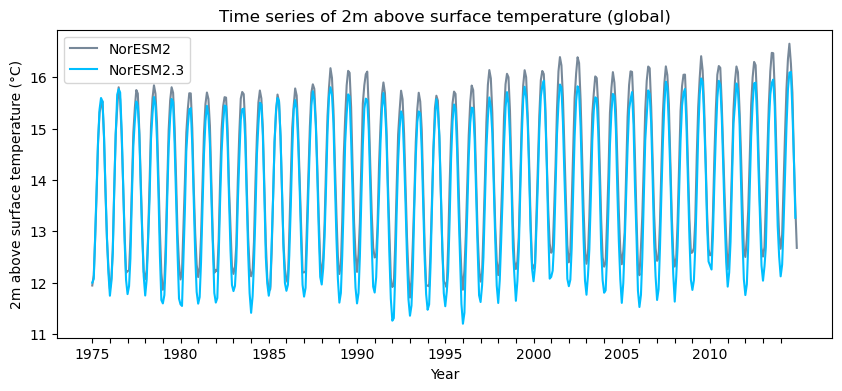

In [11]:
temp2m = "TREFHT"  

lat = m2temp["lat"]
weighted_lat = np.cos(np.deg2rad(lat))

lat_KeyClim = m2temp_KeyClim["lat"]
weighted_lat_KeyClim = np.cos(np.deg2rad(lat_KeyClim))

ts = m2temp[temp2m].weighted(weighted_lat).mean(dim=["lat", "lon"]) - 273.15 # Area-weighted mean, convert from K to °C
ts_KeyClim = m2temp_KeyClim[temp2m].weighted(weighted_lat_KeyClim).mean(dim=["lat", "lon"]) -273.15

plt.figure(figsize=(10, 4))
ts_KeyClim.plot(color="lightslategray", label="NorESM2")
ts.plot(color="deepskyblue", label="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("2m above surface temperature (°C)")
plt.xlabel("Year")
plt.title("Time series of 2m above surface temperature (global)")
plt.legend()
plt.show()

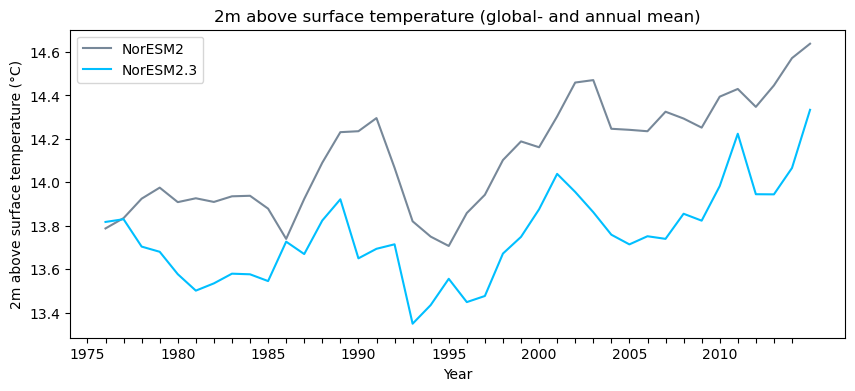

In [12]:
ts_year = ts.resample(time="1YE").mean(dim="time")
ts_KeyClim_year = ts_KeyClim.resample(time="1YE").mean(dim="time")

plt.figure(figsize=(10, 4))
ts_KeyClim_year.plot(color="lightslategray", label="NorESM2")
ts_year.plot(color="deepskyblue", label="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("2m above surface temperature (°C)")
plt.xlabel("Year")
plt.title("2m above surface temperature (global- and annual mean)")
plt.legend()
plt.show()

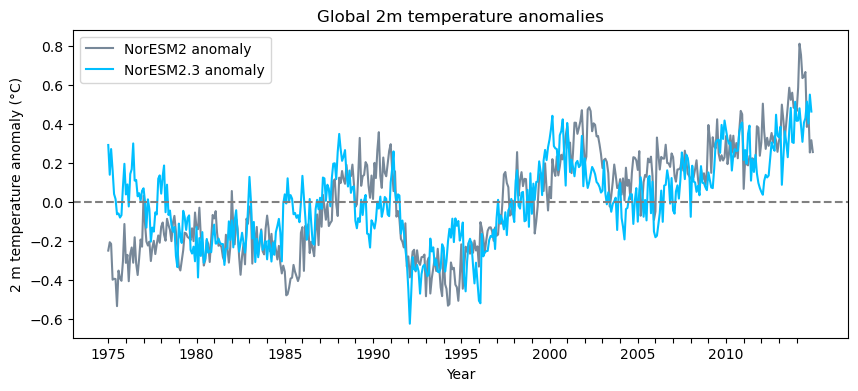

In [13]:
clim_ts = ts.groupby("time.month").mean("time")
clim_KeyClim = ts_KeyClim.groupby("time.month").mean("time")

ts_anom = ts.groupby("time.month") - clim_ts
ts_KeyClim_anom = ts_KeyClim.groupby("time.month") - clim_KeyClim

plt.figure(figsize=(10, 4))
ts_KeyClim_anom.plot(color="lightslategray", label="NorESM2 anomaly")
ts_anom.plot(color="deepskyblue", label="NorESM2.3 anomaly")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.axhline(0, linestyle='--', color='gray')
plt.ylabel("2 m temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Global 2m temperature anomalies")
plt.legend()
plt.show()

In [14]:
path = "/scratch/elihho/2m_temperature_era5_monthly/"
file_list = sorted(glob(f"{path}2m_temperature_era5_*.nc"))
ds_era5 = xr.open_mfdataset(file_list, combine="by_coords")

ds_era5['valid_time'] = ds_era5.valid_time.to_index() - pd.DateOffset(months=1)

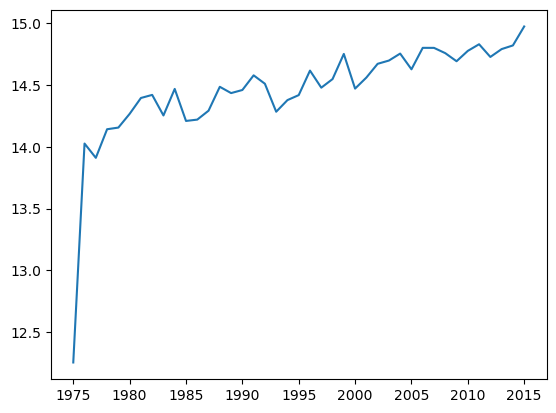

In [15]:
lat = ds_era5.latitude
weighted_lat_era5 = np.cos(np.deg2rad(lat))
t2m_era5 = ds_era5.weighted(weights=weighted_lat_era5).mean(dim=["latitude", "longitude"]) - 273.15

t2m_era5_yearly = t2m_era5.resample(valid_time="1YE").mean(dim="valid_time")
plt.plot(t2m_era5_yearly.valid_time, t2m_era5_yearly.t2m)

In [16]:
clim_era5 = t2m_era5.groupby("valid_time.month").mean("valid_time")
clim_era5

<xarray.Dataset> Size: 200B
Dimensions:  (month: 12)
Coordinates:
    number   int64 8B 0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    t2m      (month) float64 96B dask.array<chunksize=(1,), meta=np.ndarray>

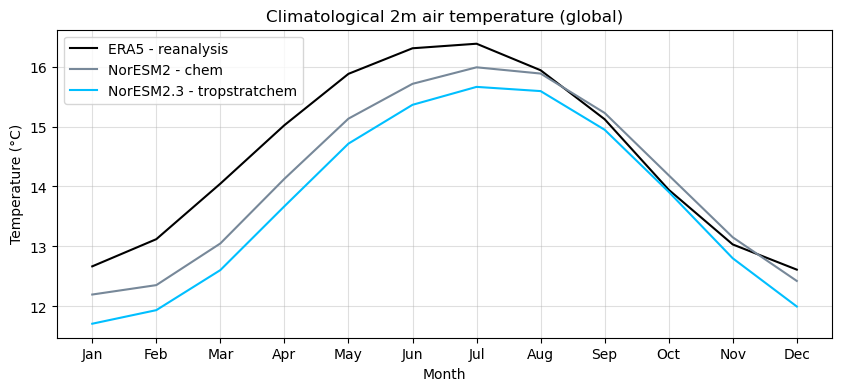

In [17]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


plt.figure(figsize=(10, 4))
plt.plot(months, clim_era5.t2m, color = "k", label="ERA5 - reanalysis")
plt.plot(months, clim_KeyClim.values, color="lightslategray", label="NorESM2 - chem")
plt.plot(months, clim_ts.values, color="deepskyblue", label="NorESM2.3 - tropstratchem")
plt.ylabel("Temperature (°C)")
plt.xlabel("Month")
plt.title("Climatological 2m air temperature (global)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

In [18]:
era5_annual = clim_era5.mean()
keyclim_annual = clim_KeyClim.mean()
tropstrat_annual = clim_ts.mean()

bias_chem = keyclim_annual - era5_annual
bias_trop = tropstrat_annual - era5_annual

bias_chem_val = bias_chem.t2m.compute().item()
bias_trop_val = bias_trop.t2m.compute().item()

print(f"Bias NorESM2-chem: {bias_chem_val:.2f} °C")
print(f"Bias NorESM2.3-tropstratchem: {bias_trop_val:.2f} °C")

Bias NorESM2-chem: -0.39 °C
Bias NorESM2.3-tropstratchem: -0.76 °C


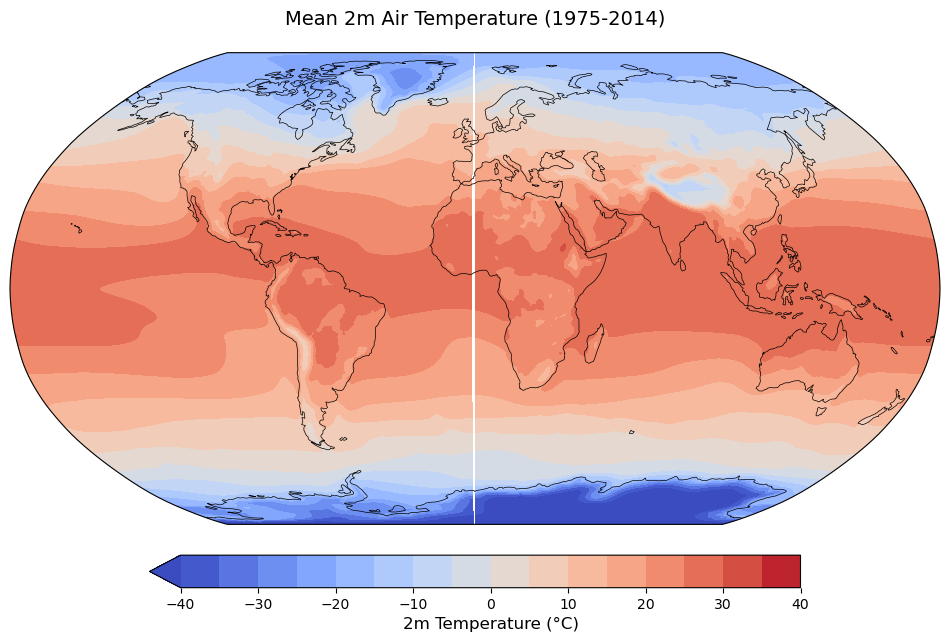

In [19]:
temp_mean_c = m2temp["TREFHT"].mean(dim='time') - 273.15

levels = np.linspace(-40, 40, 17) 

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

ax.coastlines(resolution='110m', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', alpha=0.1)

cf = ax.contourf(
    temp_mean_c.lon, temp_mean_c.lat, temp_mean_c.values,
    transform=ccrs.PlateCarree(),
    levels=levels,
    cmap='coolwarm',
    extend='min'
)

cbar = fig.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('2m Temperature (°C)', fontsize=12)

plt.title("Mean 2m Air Temperature (1975-2014)", fontsize=14, pad=20)

ax.set_global()

plt.show()

## Aerosol Optical Depth

In [20]:
aod = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/AOD_VIS_h0_1975-2014.nc")
daylight = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/DAYFOC_h0_1975-2014.nc")

aod =aod.assign_coords(time=shifted_time)
print(aod["time"].values[:5])

daylight =daylight.assign_coords(time=shifted_time)
print(daylight["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


In [21]:
aod_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/AOD_VIS_h0_1975-2014.nc")
daylight_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/DAYFOC_h0_1975-2014.nc")

aod_KeyClim =aod_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(aod_KeyClim["time"].values[:5])

daylight_KeyClim =daylight_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(daylight_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


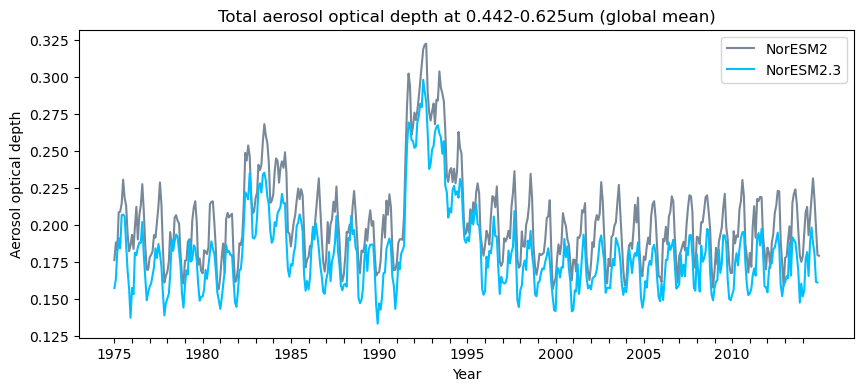

In [22]:
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
aod_volc = "AODVVOLC" # CMIP6 volcanic AOD at 0.442-0.625um
daylight_frac = "DAYFOC"  # Fraction of day in the month

ts_aod = aod[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = daylight[daylight_frac].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
ts_aod_KeyClim = aod_KeyClim[aod500].weighted(weighted_lat_KeyClim).mean(dim=["lat", "lon"])
daylight_monthly_KeyClim = daylight_KeyClim[daylight_frac].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod_KeyClim = ts_aod_KeyClim / daylight_monthly_KeyClim

plt.figure(figsize=(10, 4))
ts_aod_KeyClim.plot(color = "lightslategray", label = "NorESM2")
ts_aod.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global mean)")
plt.legend()
plt.show()

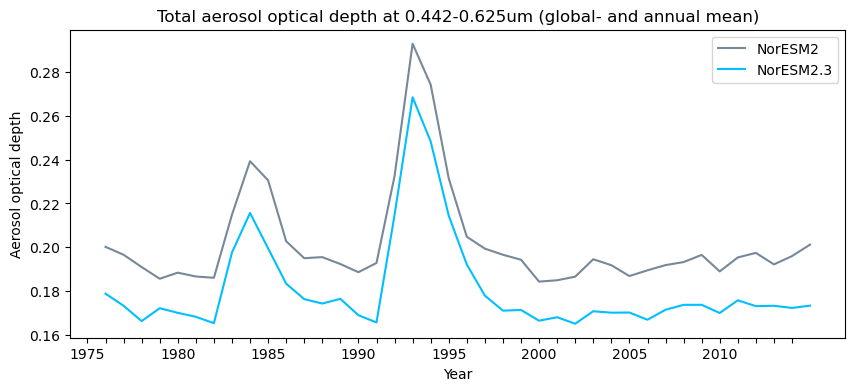

In [23]:
ts_aod_year = ts_aod.resample(time="1YE").mean()
ts_aod_KeyClim_year = ts_aod_KeyClim.resample(time="1YE").mean()

plt.figure(figsize=(10, 4))
ts_aod_KeyClim_year.plot(color = "lightslategray", label = "NorESM2")
ts_aod_year.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global- and annual mean)")
plt.legend()
plt.show()

## Wind plots

In [24]:
u = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/U_h0_1975-2014.nc")
U =u.assign_coords(time=shifted_time)

In [25]:
o3_merged = xr.open_dataset("/nird/datapeak/NS1004K/GEO4962-2026/data/prerpocessed/ESACCI-OZONE-L3-LP-SAGE_CCI_OMPS_plus_MERGED-19841001_20211201-fv0007.nc")
u_sparc = xr.open_dataset("/nird/datapeak/NS1004K/GEO4962-2026/data/SPARC/sparc.nc")
u_sparc

<xarray.Dataset> Size: 156kB
Dimensions:   (lev_wind: 46, lat: 41, month: 12, lev_temp: 33)
Coordinates:
  * lev_wind  (lev_wind) float32 184B 1e+03 681.3 464.2 ... 4.642e-05 3.162e-05
  * lat       (lat) float32 164B -80.0 -76.0 -72.0 -68.0 ... 68.0 72.0 76.0 80.0
  * month     (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * lev_temp  (lev_temp) float32 132B 1e+03 681.3 464.2 ... 0.006813 0.004642
Data variables:
    WIND      (lev_wind, lat, month) float32 91kB ...
    TEMP      (lev_temp, lat, month) float32 65kB ...
Attributes:
    creation_date:  Tue Feb 21 09:23:03 CET 2017
    creator:        D. Shea, NCAR
    Conventions:    None
    referencese:    \nRandel, W.J. et al., (2004)                            ...
    WWW_data:       http://www.sparc-climate.org/data-center/data-access/refe...
    WWW:            http://www.sparc-climate.org/
    README:         ftp://sparc-ftp1.ceda.ac.uk/sparc/ref_clim/randel/temp_wi...
    title:          SPARC Intercomparison of Middle Atmosphere Climatologies

In [26]:
u_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/U_h0_1975-2014.nc")
U_KeyClim =u_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(U_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


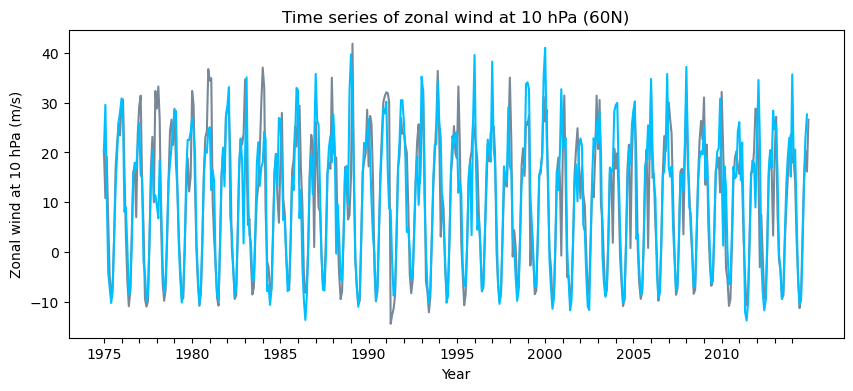

In [27]:
zonal_wind = "U"  # Zonal wind at 10 hPa
u_60N = U[zonal_wind].sel(lat=60, method="nearest")
ts_wind = u_60N.sel(lev=10, method="nearest").mean(dim="lon")
u_60N_KeyClim = U_KeyClim[zonal_wind].sel(lat=60, method="nearest")
ts_wind_KeyClim = u_60N_KeyClim.sel(lev=10, method="nearest").mean(dim="lon")

plt.figure(figsize=(10, 4))
ts_wind_KeyClim.plot(color = "lightslategray", label = "NorESM2")
ts_wind.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("Zonal wind at 10 hPa (m/s)")
plt.title("Time series of zonal wind at 10 hPa (60N)")
plt.show()

/tmp/ipykernel_550528/4269633857.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.96])


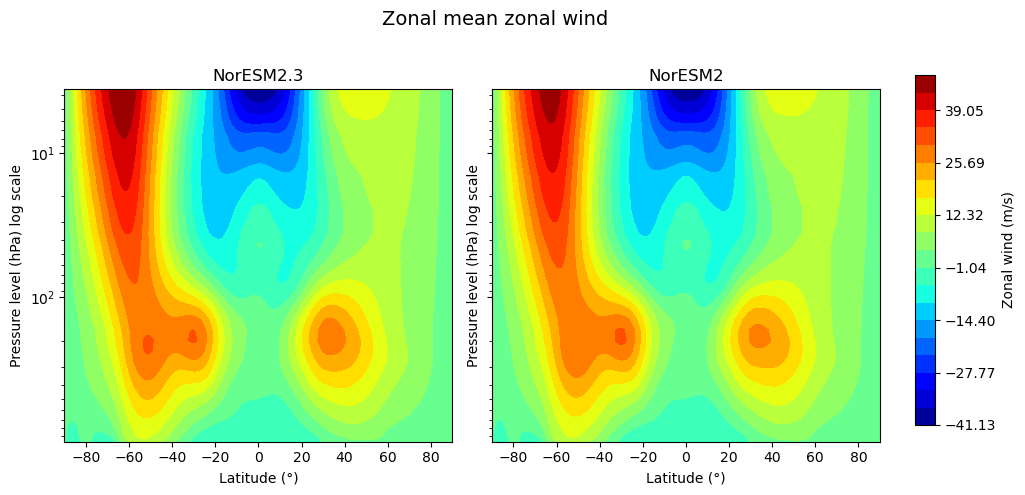

In [28]:
U = U[zonal_wind].mean(dim="lon")
u_lat = U["lat"].values
u_lev = U["lev"].values
U_mean = U.mean(dim="time")
U_mean = U_mean.transpose("lev", "lat")
U_mean = U_mean.values

U_KeyClim = U_KeyClim[zonal_wind].mean(dim="lon")
u_lat_KeyClim = U_KeyClim["lat"].values
u_lev_KeyClim = U_KeyClim["lev"].values
U_mean_KeyClim = U_KeyClim.mean(dim="time")
U_mean_KeyClim = U_mean_KeyClim.transpose("lev", "lat")
U_mean_KeyClim = U_mean_KeyClim.values

vmin = min(U_mean.min(), U_mean_KeyClim.min())
vmax = max(U_mean.max(), U_mean_KeyClim.max())
levels = np.linspace(vmin, vmax, 21)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax = ax.flatten()

# NorESM2.3
ax[0].set_yscale("log")
cf0 = ax[0].contourf(u_lat, u_lev, U_mean, cmap="jet", levels=levels)
ax[0].set_ylim(u_lev.max(), u_lev.min())
ax[0].set_xlabel("Latitude (°)")
ax[0].set_ylabel("Pressure level (hPa) log scale")
ax[0].set_title("NorESM2.3")

# KeyClim
ax[1].set_yscale("log")
cf1 = ax[1].contourf(u_lat_KeyClim, u_lev_KeyClim, U_mean_KeyClim, cmap="jet", levels=levels)
ax[1].set_ylim(u_lev.max(), u_lev.min())
ax[1].set_xlabel("Latitude (°)")
ax[1].set_ylabel("Pressure level (hPa) log scale")
ax[1].set_title("NorESM2")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(cf0, cax=cbar_ax, label="Zonal wind (m/s)")
fig.suptitle("Zonal mean zonal wind", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.96]) 
plt.show()

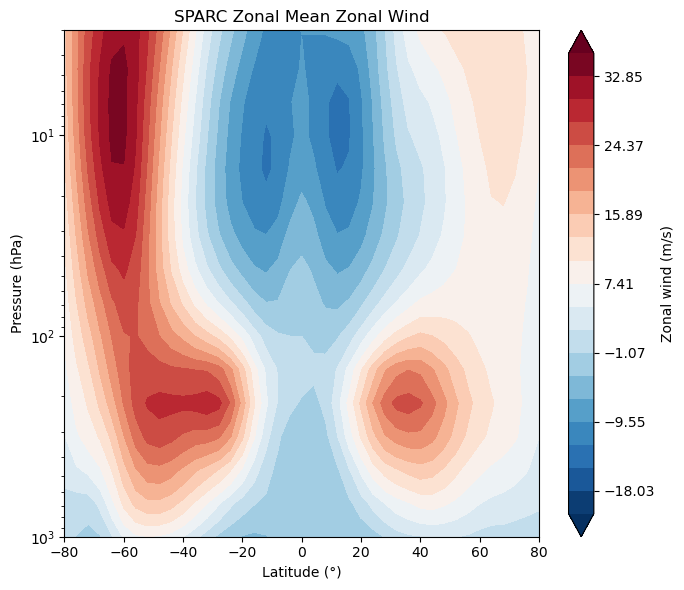

In [29]:
u_lat_sparc = u_sparc["lat"].values
u_lev_sparc = u_sparc["lev_wind"].values
U_mean_sparc = u_sparc["WIND"].mean(dim="month") 

vmin = U_mean_sparc.min().values
vmax = U_mean_sparc.max().values
levels = np.linspace(vmin, vmax, 21)

fig, ax = plt.subplots(figsize=(7, 6)) 

ax.set_yscale("log")
cf0 = ax.contourf(u_lat_sparc, u_lev_sparc, U_mean_sparc, cmap="RdBu_r", levels=levels, extend='both')

ax.set_ylim(1000, 3) 
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("SPARC Zonal Mean Zonal Wind")

cbar = fig.colorbar(cf0, ax=ax, label="Zonal wind (m/s)", pad=0.05)

plt.tight_layout()
plt.show()

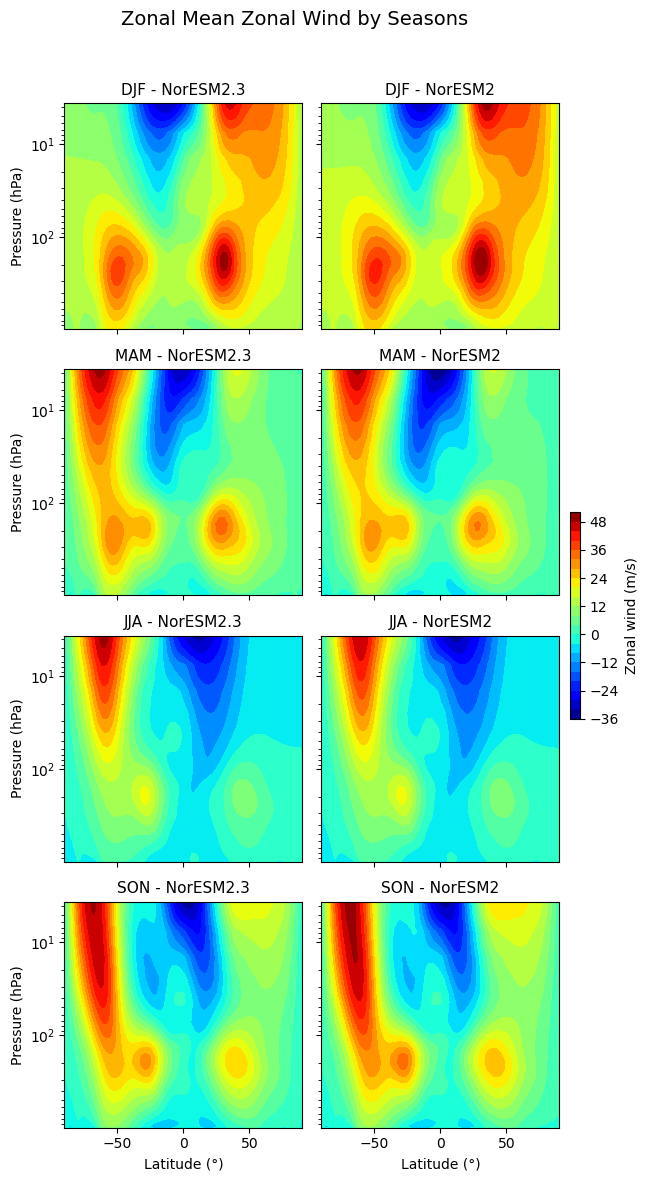

In [30]:
U_seasons = U.groupby("time.season")
U_season_KeyClim = U_KeyClim.groupby("time.season")

season_order = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(4, 2, figsize=(6, 12), sharex=True, sharey=True)

for i, season in enumerate(season_order):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    if season in U_seasons.groups:
        data1 = U_seasons[season]
        U_meanseason1 = data1.mean(dim="time").transpose("lev", "lat")
        cf1 = ax_left.contourf(u_lat, u_lev, U_meanseason1.values, cmap="jet", levels=21)
        ax_left.set_yscale("log")
        ax_left.set_ylim(u_lev.max(), u_lev.min())
        ax_left.set_title(f"{season} - NorESM2.3", fontsize=11)
        ax_left.set_ylabel("Pressure (hPa)")
        if i == len(season_order) - 1:
            ax_left.set_xlabel("Latitude (°)")

    if season in U_season_KeyClim.groups:
        data2 = U_season_KeyClim[season]
        U_meanseason2 = data2.mean(dim="time").transpose("lev", "lat")
        cf2 = ax_right.contourf(u_lat, u_lev, U_meanseason2.values, cmap="jet", levels=21)
        ax_right.set_yscale("log")
        ax_right.set_ylim(u_lev.max(), u_lev.min())
        ax_right.set_title(f"{season} - NorESM2", fontsize=11)
        if i == len(season_order) - 1:
            ax_right.set_xlabel("Latitude (°)")

fig.suptitle("Zonal Mean Zonal Wind by Seasons", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
cbar = fig.colorbar(cf2, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Zonal wind (m/s)")

plt.show()


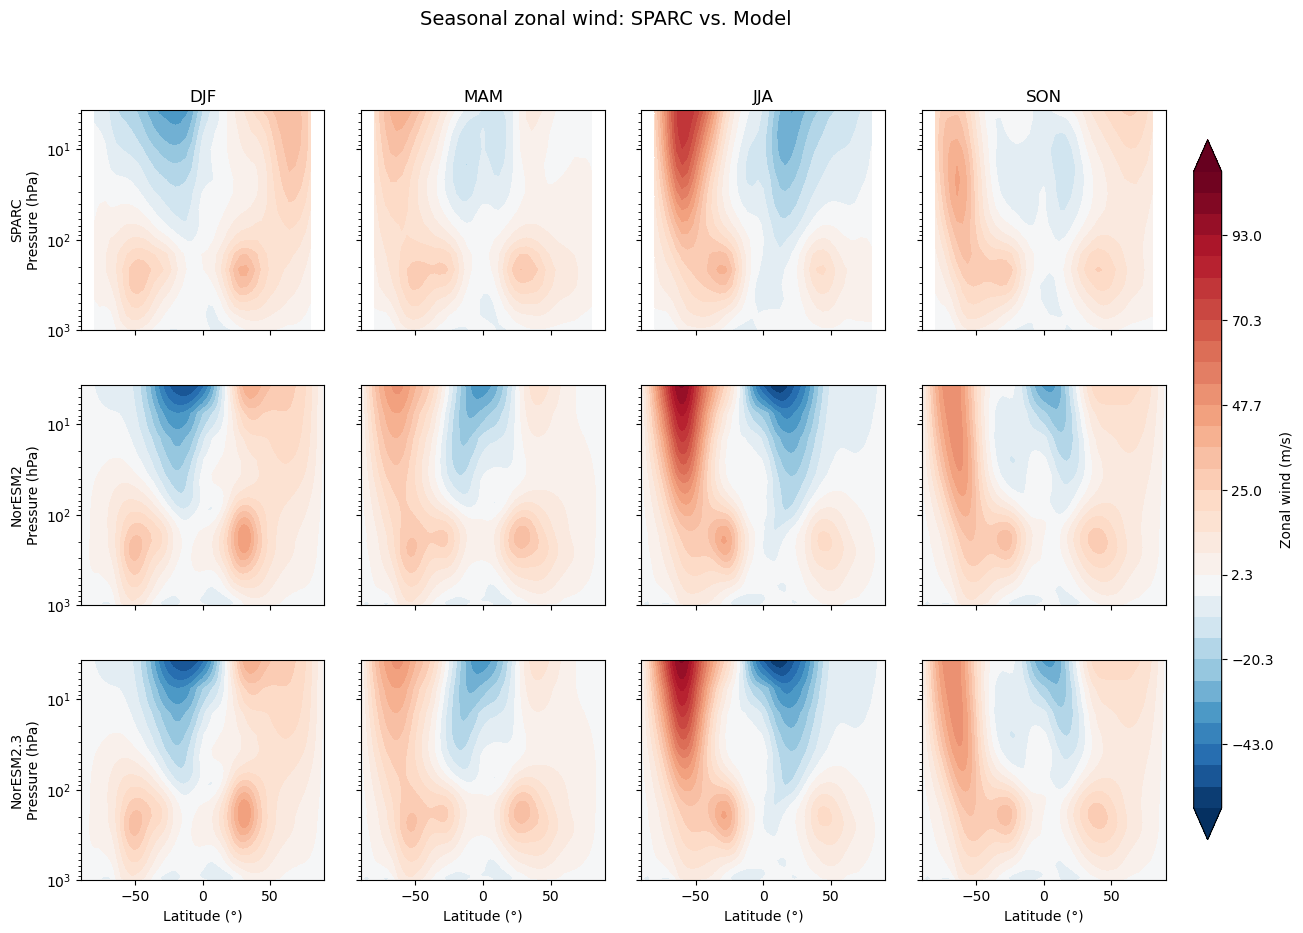

In [31]:
seasons_map = ["DJF", "DJF", "MAM", "MAM", "MAM", "JJA", "JJA", "JJA", "SON", "SON", "SON", "DJF"]
u_sparc_with_seasons = u_sparc["WIND"].assign_coords(season=("month", seasons_map))

u_sparc_seasons = u_sparc_with_seasons.groupby("season")

season_order = ["DJF", "MAM", "JJA", "SON"]
datasets = ["SPARC", "NorESM2", "NorESM2.3"]

fig, axes = plt.subplots(3, 4, figsize=(14, 10), sharex=True, sharey='row')

levels = np.linspace(-60, 110, 31) 
v_min, v_max = -60, 110
norm = TwoSlopeNorm(vmin=v_min, vcenter=0, vmax=v_max)

for row, ds_name in enumerate(datasets):
    for col, season in enumerate(season_order):
        ax = axes[row, col]
        
        if ds_name == "SPARC":
            data = u_sparc_seasons[season].mean(dim="month").transpose("lev_wind", "lat")
            lats, levs = u_lat_sparc, u_lev_sparc
        elif ds_name == "KeyClim":
            data = U_season_KeyClim[season].mean(dim="time").transpose("lev", "lat")
            lats, levs = u_lat, u_lev
        else: 
            data = U_seasons[season].mean(dim="time").transpose("lev", "lat")
            lats, levs = u_lat, u_lev

        cf = ax.contourf(lats, levs, data.values, cmap="RdBu_r", norm=norm, levels=levels, extend='both')
        
        ax.set_yscale("log")
        ax.set_ylim(1000, 3.643466)
        
        if row == 0:
            ax.set_title(season, fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{ds_name}\nPressure (hPa)", fontsize=10)
        if row == 2:
            ax.set_xlabel("Latitude (°)")

fig.subplots_adjust(right=0.9, hspace=0.25, wspace=0.15)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(cf, cax=cbar_ax, label="Zonal wind (m/s)")

fig.suptitle("Seasonal zonal wind: SPARC vs. Model", fontsize=14, y=0.98)
plt.show()

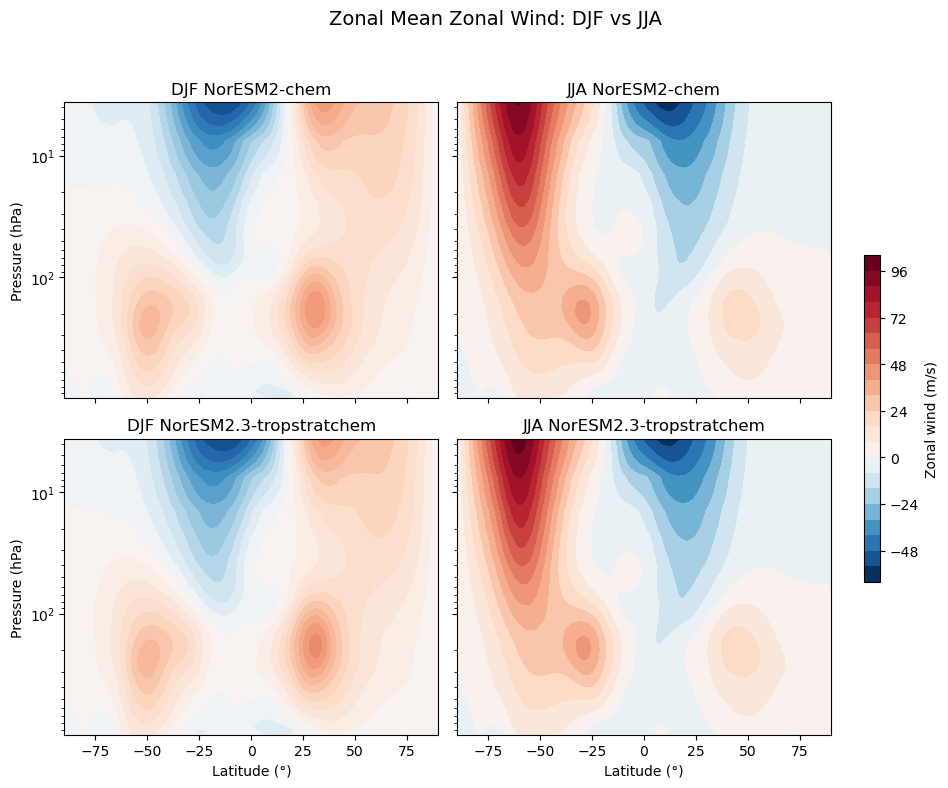

In [32]:
selected_seasons = ["DJF", "JJA"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

v_min, v_max = -60, 100 
norm = TwoSlopeNorm(vmin=v_min, vcenter=0, vmax=v_max)

for j, season in enumerate(selected_seasons):
    ax_top = axes[0, j]
    ax_bottom = axes[1, j]

    if season in U_season_KeyClim.groups:
        data2 = U_season_KeyClim[season]
        U_meanseason2 = data2.mean(dim="time").transpose("lev", "lat")
        cf2 = ax_top.contourf(u_lat, u_lev, U_meanseason2.values, cmap="RdBu_r", norm = norm, levels=21) #, extend='both')
        ax_top.set_yscale("log")
        ax_top.set_ylim(u_lev.max(), u_lev.min())
        ax_top.set_title(f"{season} NorESM2-chem", fontsize=12)
        if j == 0:
            ax_top.set_ylabel("Pressure (hPa)")

    if season in U_seasons.groups:
        data1 = U_seasons[season]
        U_meanseason1 = data1.mean(dim="time").transpose("lev", "lat")
        cf1 = ax_bottom.contourf(u_lat, u_lev, U_meanseason1.values, cmap="RdBu_r", norm = norm, levels=21) #, extend='both')
        ax_bottom.set_yscale("log")
        ax_bottom.set_ylim(u_lev.max(), u_lev.min())
        ax_bottom.set_title(f"{season} NorESM2.3-tropstratchem", fontsize=12)
        ax_bottom.set_xlabel("Latitude (°)")
        if j == 0:
            ax_bottom.set_ylabel("Pressure (hPa)")



fig.suptitle("Zonal Mean Zonal Wind: DJF vs JJA", fontsize=14)
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) 

cbar = fig.colorbar(cf2, ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("Zonal wind (m/s)")

plt.show()

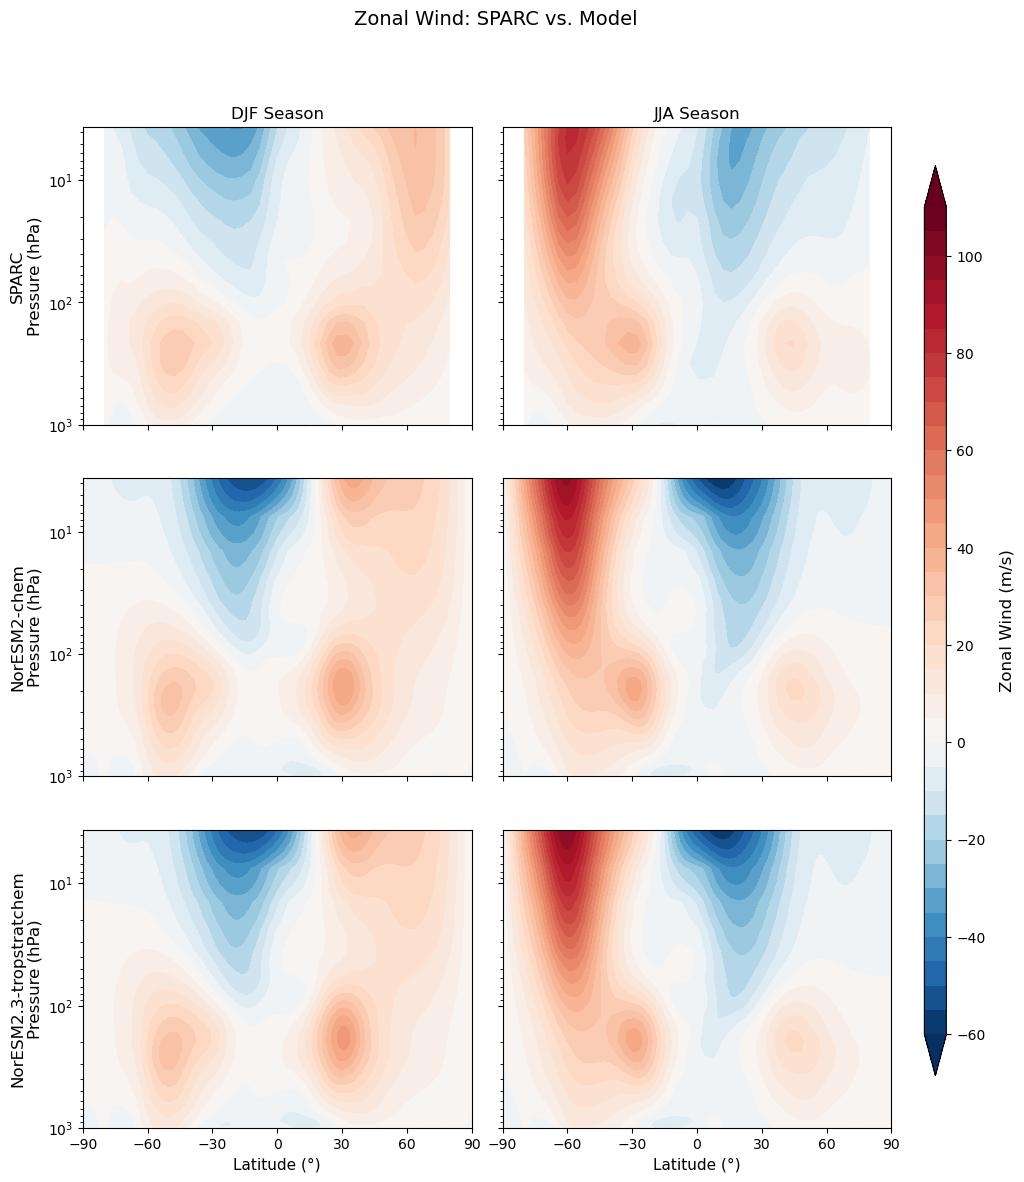

In [33]:
selected_seasons = ["DJF", "JJA"]
datasets = ["SPARC", "NorESM2-chem", "NorESM2.3-tropstratchem"]

fig, axes = plt.subplots(3, 2, figsize=(11, 13), sharex=True, sharey='row')

v_min, v_max = -60, 110 
norm = TwoSlopeNorm(vmin=v_min, vcenter=0, vmax=v_max)
levels = np.linspace(v_min, v_max, 35)

for row, ds_name in enumerate(datasets):
    for col, season in enumerate(selected_seasons):
        ax = axes[row, col]
        
        if ds_name == "SPARC":
            data = u_sparc_seasons[season].mean(dim="month").transpose("lev_wind", "lat")
            lats, levs = u_lat_sparc, u_lev_sparc
        elif ds_name == "NorESM2-chem":
            data = U_season_KeyClim[season].mean(dim="time").transpose("lev", "lat")
            lats, levs = u_lat, u_lev
        else:
            data = U_seasons[season].mean(dim="time").transpose("lev", "lat")
            lats, levs = u_lat, u_lev

        cf = ax.contourf(lats, levs, data.values, 
                         cmap="RdBu_r", norm=norm, levels=levels, extend='both')
        
        ax.set_yscale("log")
        ax.set_ylim(1000, 3.643466)
        
        if row == 0:
            ax.set_title(f"{season} Season", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{ds_name}\nPressure (hPa)", fontsize=12)
        if row == 2:
            ax.set_xlabel("Latitude (°)", fontsize=11)
            ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])

fig.subplots_adjust(right=0.86, hspace=0.18, wspace=0.08)

cbar_ax = fig.add_axes([0.89, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label("Zonal Wind (m/s)", fontsize=12, labelpad=10)

fig.suptitle("Zonal Wind: SPARC vs. Model", fontsize=14, y=0.97)

plt.show()

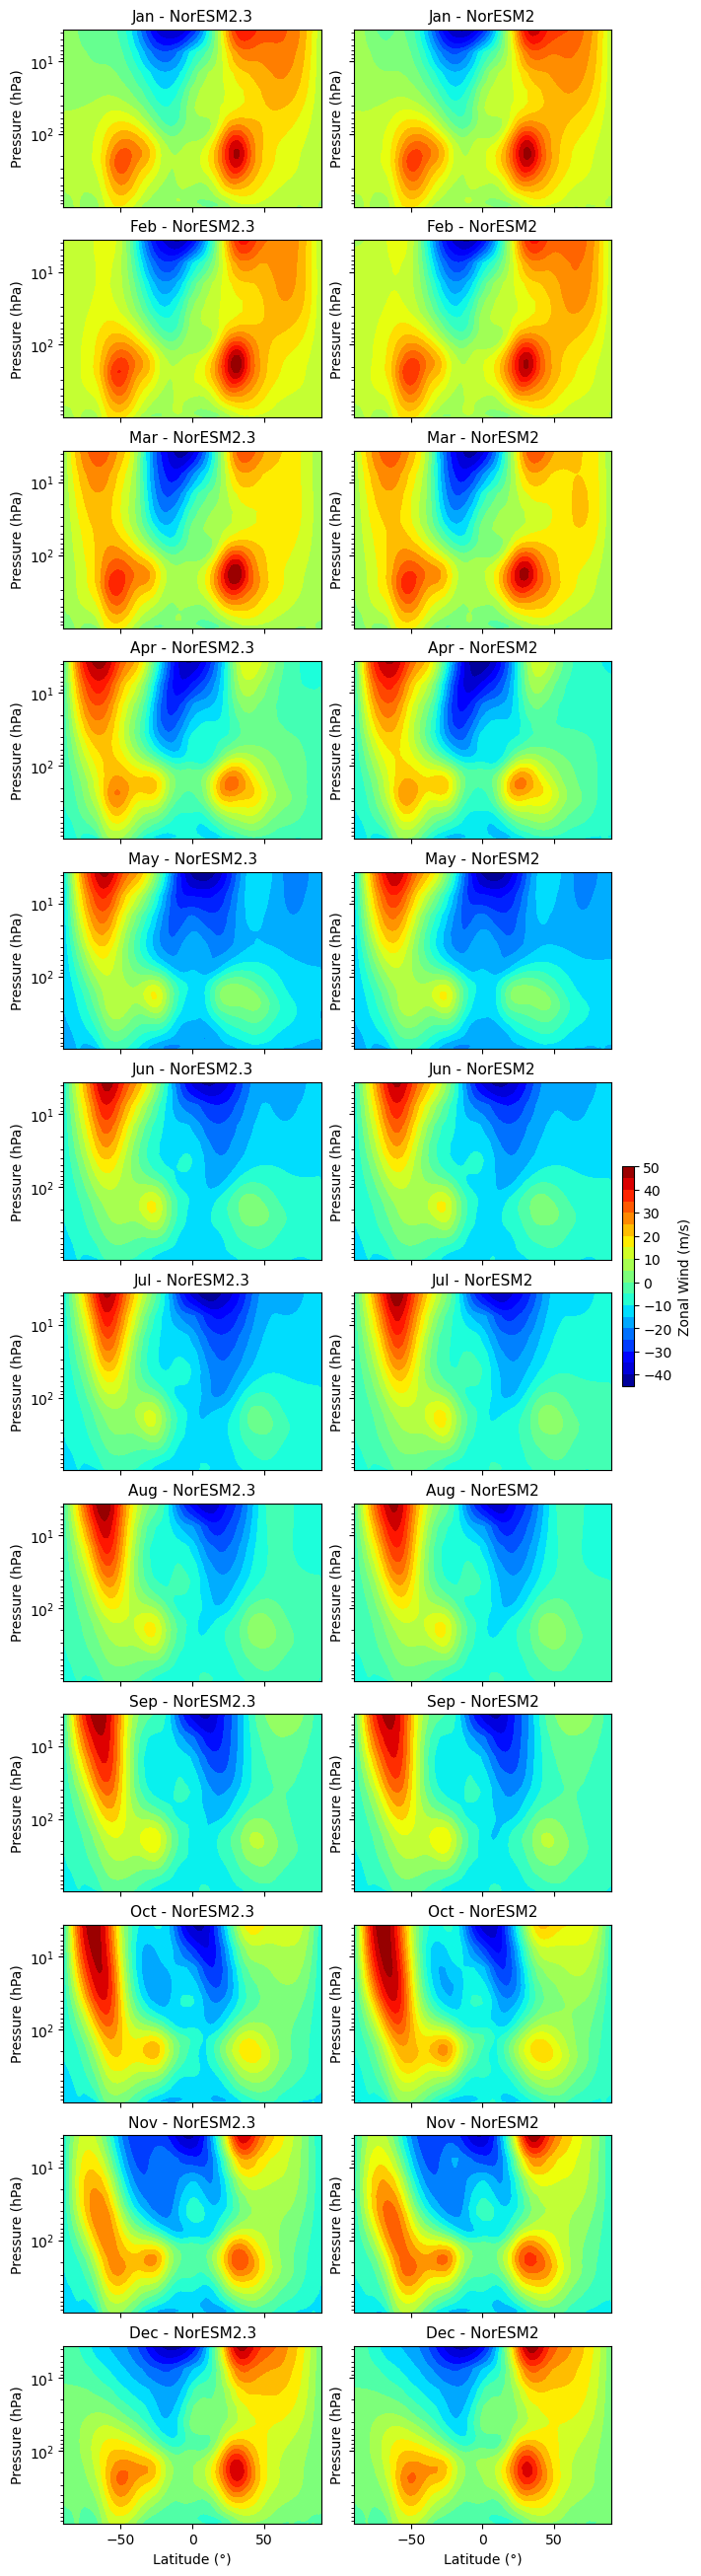

In [34]:
U_monthly = U.groupby("time.month")
U_monthly_KeyClim = U_KeyClim.groupby("time.month")

month_labels = ["Jan", "Feb", "Mar", "Apr", 
                "May", "Jun", "Jul", "Aug", 
                "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(
    nrows=12, ncols=2, figsize=(7, 26),
    sharex=True, sharey=True, constrained_layout=True
)

def plot_zonal_mean(ax, data_group, month_idx, model_name):
    if month_idx not in data_group.groups:
        return None

    data = data_group[month_idx]
    U_mean = data.mean(dim="time").transpose("lev", "lat")
    cf = ax.contourf(u_lat, u_lev, U_mean, cmap="jet", levels=21)
    ax.set_yscale("log")
    ax.set_ylim(u_lev.max(), u_lev.min())
    ax.set_title(f"{month_labels[month_idx - 1]} - {model_name}", fontsize=11)

    if month_idx == 12:
        ax.set_xlabel("Latitude (°)")
    ax.set_ylabel("Pressure (hPa)")

    return cf

for i, month_name in enumerate(month_labels, start=1):
    ax_left, ax_right = axes[i-1, :]

    cf1 = plot_zonal_mean(ax_left, U_monthly, month_idx=i, model_name="NorESM2.3")
    cf2 = plot_zonal_mean(ax_right, U_monthly_KeyClim, month_idx=i, model_name="NorESM2")


cf_final = cf2 or cf1
if cf_final:
    cbar = fig.colorbar(cf_final, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
    cbar.set_label("Zonal Wind (m/s)")

plt.show()

In [35]:
p_levels = [
    1000.0, 975.0, 950.0, 925.0, 900.0, 875.0, 850.0, 825.0, 800.0, 775.0, 
    750.0, 725.0, 700.0, 650.0, 600.0, 550.0, 500.0, 450.0, 400.0, 350.0, 
    300.0, 250.0, 200.0, 150.0, 100.0, 70.0, 50.0, 40.0, 30.0, 20.0, 
    10.0, 7.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.7, 0.5, 0.4, 0.3, 0.1
]

file_path = "/nird/datapeak/NS1004K/elihho/QBO_MERRA2-Uvals_00N_GSFC.txt"
df = pd.read_csv(file_path, sep='\s+', skiprows=16, header=None)

df.columns = ['YYYYMM'] + p_levels

df['time'] = pd.to_datetime(df['YYYYMM'].astype(str), format='%Y%m')
qbo_obs = df.set_index('time').drop(columns=['YYYYMM'])

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_550528/33187911.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', skiprows=16, header=None)


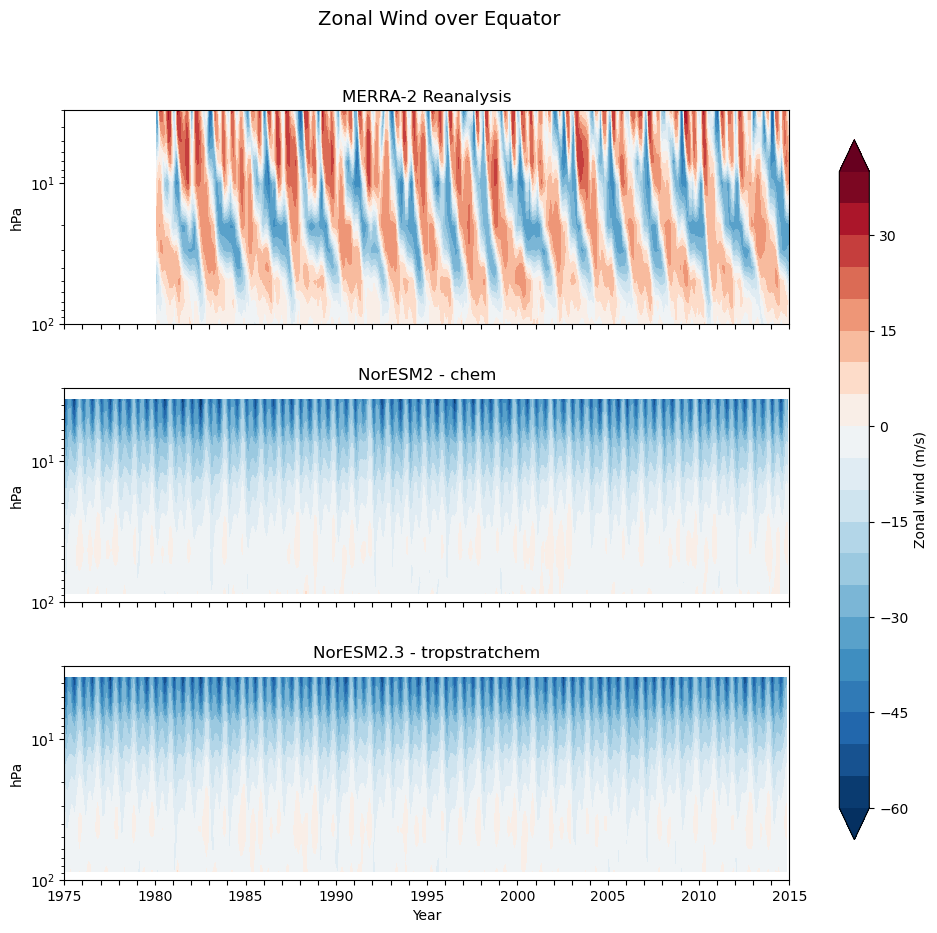

In [36]:
U_eq = U.sel(lat=slice(-5, 5))
U_eq = U_eq.where(U_eq["lev"] <= 100)
U_eq = U_eq.weighted(weights=weighted_lat).mean(dim="lat")

U_eq_KeyClim = U_KeyClim.sel(lat=slice(-5, 5))
U_eq_KeyClim = U_eq_KeyClim.where(U_eq_KeyClim["lev"] <= 100)
U_eq_KeyClim = U_eq_KeyClim.weighted(weights=weighted_lat_KeyClim).mean(dim="lat")

qbo_obs_time_cftime = [cftime.DatetimeNoLeap(t.year, t.month, t.day) for t in qbo_obs.index]

fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

years = np.arange(1975, 2016)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]

v_min, v_max = -60, 40
norm = TwoSlopeNorm(vmin=v_min, vcenter=0, vmax=v_max)
levels = np.linspace(v_min, v_max, 21)
obs_levels = qbo_obs.columns.astype(float)
cf0 = ax[0].contourf(qbo_obs_time_cftime, obs_levels, qbo_obs.values.T, 
                     cmap="RdBu_r", levels=levels, norm = norm, extend='both')
ax[0].set_yscale("log")
ax[0].set_ylim(100, 3) 
ax[0].set_xlim(1975, 2014)
ax[0].set_title("MERRA-2 Reanalysis", fontsize=12)
ax[0].set_ylabel("hPa")

cf1 = ax[1].contourf(U_eq_KeyClim["time"].values, U_eq_KeyClim["lev"].values, U_eq_KeyClim.T, 
                     cmap="RdBu_r", levels=levels, norm = norm, extend='both')
ax[1].set_yscale("log")
ax[1].set_ylim(100, 3) 
ax[1].set_title("NorESM2 - chem", fontsize=12)
ax[1].set_ylabel("hPa")

cf2 = ax[2].contourf(U_eq["time"].values, U_eq["lev"].values, U_eq.T, 
                     cmap="RdBu_r", levels=levels, norm = norm, extend='both')
ax[2].set_yscale("log")
ax[2].set_ylim(100, 3) 
ax[2].set_title("NorESM2.3 - tropstratchem", fontsize=12)
ax[2].set_ylabel("hPa")
ax[2].set_xlabel("Year")

ax[2].set_xticks(year_ticks)
ax[2].set_xticklabels([str(y) if y % 5 == 0 else '' for y in years])

cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar = fig.colorbar(cf2, cax = cbar_ax)
cbar.set_label("Zonal wind (m/s)")

fig.suptitle("Zonal Wind over Equator", fontsize=14)
fig.subplots_adjust(hspace=0.3, right=0.85) 

plt.show()


In [37]:
# Helper function to set latitudinal limits
# from https://nordicesmhub.github.io/NEGI-Abisko-2019/training/example_NorthPolarStereo_projection.html
def polarCentral_set_latlim(lat_lims, ax):
    # Set extent in geographic coordinates
    ax.set_extent([-180, 180, lat_lims[0], lat_lims[1]], crs=ccrs.PlateCarree())

    # Make circular boundary (center of axes)
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
"""
fig, ax = plt.subplots(
    1, 1,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    constrained_layout=True
)

mean_u = ds[zonal_wind].sel(lev = 10, method = "nearest").mean(dim="time")
polarCentral_set_latlim((20, 90), ax)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=False, linewidth=0.2)

mean_u.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",
    center=0,
)

plt.suptitle("Zonal wind at 10 hPa (m/s)", fontsize=16)
plt.show()
"""


'\nfig, ax = plt.subplots(\n    1, 1,\n    figsize=(16, 8),\n    subplot_kw={\'projection\': ccrs.NorthPolarStereo()},\n    constrained_layout=True\n)\n\nmean_u = ds[zonal_wind].sel(lev = 10, method = "nearest").mean(dim="time")\npolarCentral_set_latlim((20, 90), ax)\nax.add_feature(cfeature.COASTLINE, linewidth=0.5)\nax.add_feature(cfeature.BORDERS, linewidth=0.3)\nax.gridlines(draw_labels=False, linewidth=0.2)\n\nmean_u.plot(\n    ax=ax,\n    transform=ccrs.PlateCarree(),\n    cmap="Spectral_r",\n    center=0,\n)\n\nplt.suptitle("Zonal wind at 10 hPa (m/s)", fontsize=16)\nplt.show()\n'

In [38]:
"""
fig, ax = plt.subplots(
    1, 1,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.SouthPolarStereo()},
    constrained_layout=True
)

polarCentral_set_latlim((-90, -20), ax)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=False, linewidth=0.2)

mean_u.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",
    center=0,
)

plt.suptitle("Zonal wind at 10 hPa (m/s)", fontsize=16)
plt.show()
"""


'\nfig, ax = plt.subplots(\n    1, 1,\n    figsize=(16, 8),\n    subplot_kw={\'projection\': ccrs.SouthPolarStereo()},\n    constrained_layout=True\n)\n\npolarCentral_set_latlim((-90, -20), ax)\nax.add_feature(cfeature.COASTLINE, linewidth=0.5)\nax.add_feature(cfeature.BORDERS, linewidth=0.3)\nax.gridlines(draw_labels=False, linewidth=0.2)\n\nmean_u.plot(\n    ax=ax,\n    transform=ccrs.PlateCarree(),\n    cmap="Spectral_r",\n    center=0,\n)\n\nplt.suptitle("Zonal wind at 10 hPa (m/s)", fontsize=16)\nplt.show()\n'

## Ozone

In [39]:
o3_surf = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/O3_SRF_h0_1975-2014.nc")
o3_surf =o3_surf.assign_coords(time=shifted_time)

In [40]:
o3_surf_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/O3_SRF_h0_1975-2014.nc")
o3_surf_KeyClim =o3_surf_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(o3_surf_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


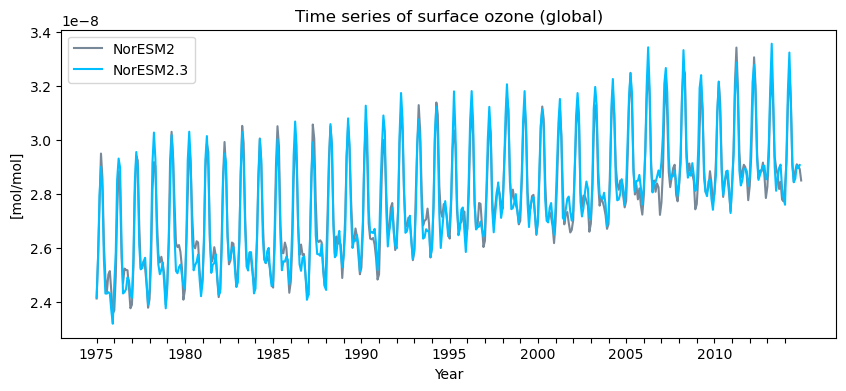

In [41]:
surf_o3 = "O3_SRF"
ts_o3 = o3_surf[surf_o3].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_o3_KeyClim = o3_surf_KeyClim[surf_o3].weighted(weighted_lat).mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
ts_o3_KeyClim.plot(color="lightslategray", label = "NorESM2")
ts_o3.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("[mol/mol]")
plt.xlabel("Year")
plt.title("Time series of surface ozone (global)")
plt.legend() 
plt.show()

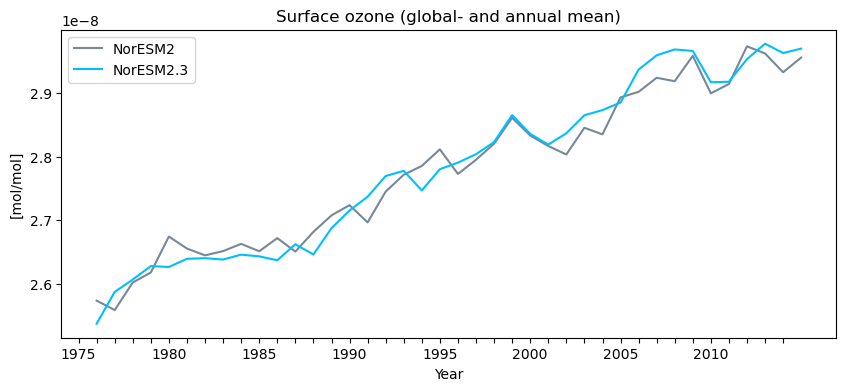

In [42]:
ts_o3_year = ts_o3.resample(time="1YE").mean()
ts_o3_KeyClim_year = ts_o3_KeyClim.resample(time="1YE").mean()

plt.figure(figsize=(10, 4))
ts_o3_KeyClim_year.plot(color="lightslategray", label = "NorESM2")
ts_o3_year.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("[mol/mol]")
plt.xlabel("Year")
plt.title("Surface ozone (global- and annual mean)")
plt.legend()
plt.show()

In [43]:
o3 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/O3_h0_1975-2014.nc")
o3 =o3.assign_coords(time=shifted_time)

cb_o3 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/cb_O3_h0_1975-2014.nc")
cb_o3 = cb_o3.assign_coords(time=shifted_time)

In [44]:
o3_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/O3_h0_1975-2014.nc")

o3_KeyClim =o3_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(o3_KeyClim["time"].values[:5])

cb_o3_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/cb_O3_h0_1975-2014.nc")
cb_o3_KeyClim = cb_o3_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(cb_o3_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


In [45]:
o3_merged

<xarray.Dataset> Size: 58MB
Dimensions:                                  (time: 447, latitude_centers: 18,
                                              altitude: 41, instruments: 9)
Coordinates:
  * time                                     (time) datetime64[ns] 4kB 1984-1...
  * latitude_centers                         (latitude_centers) float32 72B -...
  * altitude                                 (altitude) float32 164B 10.0 ......
  * instruments                              (instruments) int16 18B 1 2 ... 8 9
Data variables:
    merged_ozone_anomaly                     (latitude_centers, altitude, time) float64 3MB ...
    uncertainty_of_merged_ozone              (latitude_centers, altitude, time) float64 3MB ...
    merged_ozone_concentration               (latitude_centers, altitude, time) float64 3MB ...
    temperature                              (latitude_centers, altitude, time) float32 1MB ...
    pressure                                 (latitude_centers, altitude, time) float32 1MB ...
    ozone_anomaly_instrument                 (instruments, latitude_centers, altitude, time) float64 24MB ...
    uncertainty_of_ozone_anomaly_instrument  (instruments, latitude_centers, altitude, time) float64 24MB ...
Attributes: (12/38)
    title:                         Merged SAGE-CCI-OMPS+ dataset of ozone pro...
    summary:                       SAGE-CCI-OMPS+ dataset contais the merged ...
    comment:                       The deseasonalized anomalies from individu...
    history:                       2017: the SAGE-CCI-OMPS first release,  re...
    references:                    https://climate.esa.int/en/projects/ozone/...
    source:                        Level 2 ozone profiles from SAGE II NASA v...
    ...                            ...
    value_for_nodata:              NaN
    standard_name_vocabulary:      CF Standard Name Table v77
    license:                       ESA CCI Data Policy: free and open access
    platform:                      Envisat, Odin, SciSat, Suomi-NPP, ERBS, IS...
    sensor:                        MIPAS, GOMOS, SCIAMACHY, OSIRIS, ACE-FTS, ...
    key_variables:                 merged_ozone_anomaly, merged_ozone_concent...

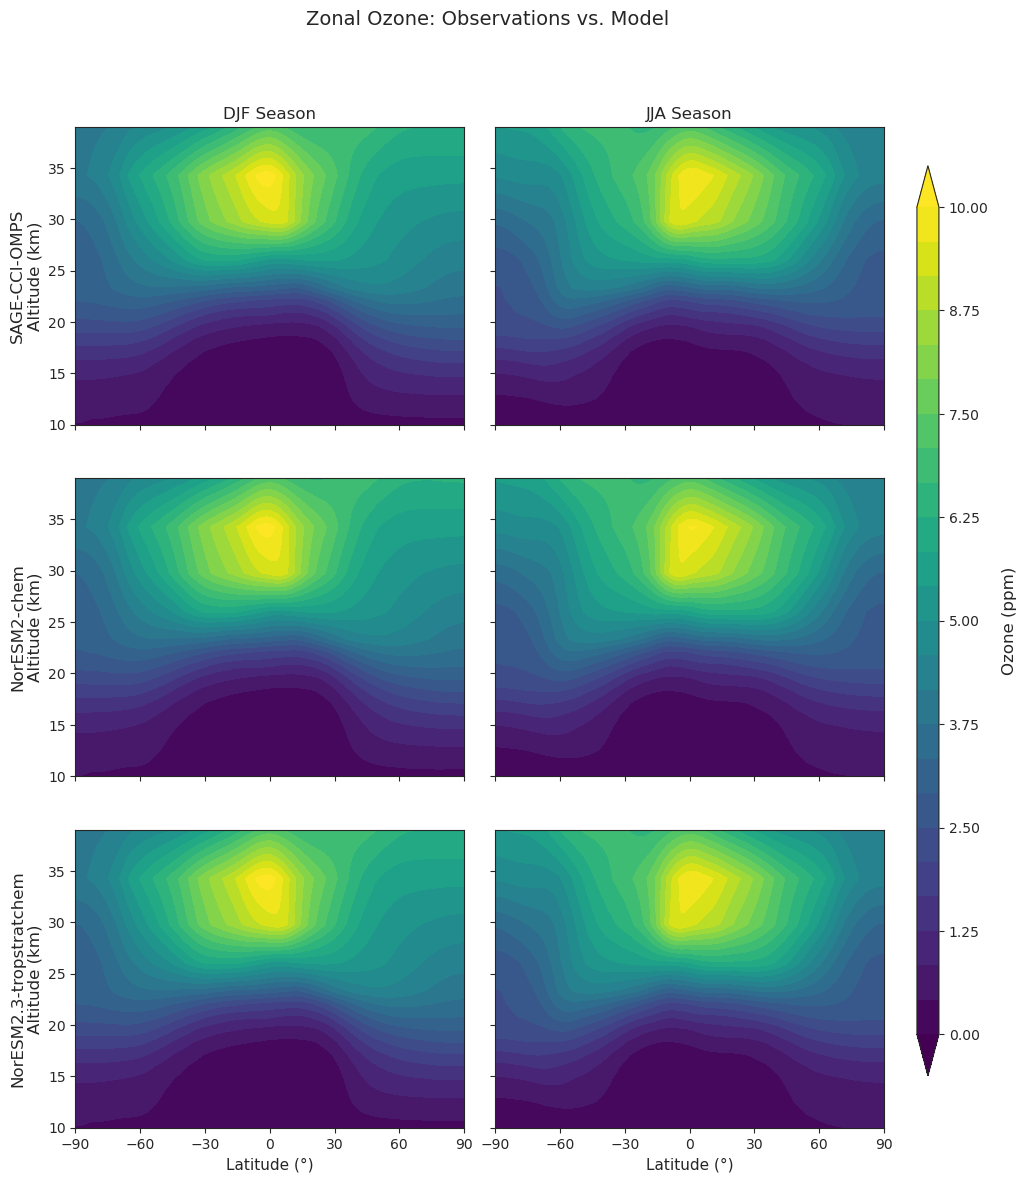

In [103]:
pressure_pa = o3_merged['pressure'] * 100 
R = 8.314

sage_ppm = (o3_merged['merged_ozone_concentration'] * R * o3_merged['temperature']) / pressure_pa
sage_ppm = sage_ppm * 1e6 
sage_seasonal = sage_ppm.groupby('time.season').mean(dim='time')

H = 7
P0 = 1013.25 

for ds in [o3_KeyClim, o3]:
    ds.coords['z'] = H * np.log(P0 / ds.lev)

chem_seasonal = o3_KeyClim['O3'].groupby('time.season').mean(dim=['time', 'lon'])
trop_seasonal = o3['O3'].groupby('time.season').mean(dim=['time', 'lon'])

selected_seasons = ["DJF", "JJA"]
datasets = ["SAGE-CCI-OMPS", "NorESM2-chem", "NorESM2.3-tropstratchem"]
norm = Normalize(vmin=0, vmax=10)
levels = np.linspace(0, 10, 21)

fig, axes = plt.subplots(3, 2, figsize=(11, 13), sharex=True, sharey=True)

norm = Normalize(vmin=0, vmax=10)
levels = np.linspace(0, 10, 25) 

for row, ds_name in enumerate(datasets):
    for col, season in enumerate(selected_seasons):
        ax = axes[row, col]
        
        if ds_name == "SAGE-CCI (Obs)":
            data = sage_seasonal.sel(season=season).transpose("altitude", "latitude_centers")
            lats, heights = o3_merged.latitude_centers, o3_merged.altitude
        elif ds_name == "NorESM2-chem":
            data = chem_seasonal.sel(season=season).transpose("lev", "lat") * 1e6
            lats, heights = o3_KeyClim.lat, o3_KeyClim.z
        else: 
            data = trop_seasonal.sel(season=season).transpose("lev", "lat") * 1e6
            lats, heights = o3.lat, o3.z

        cf = ax.contourf(lats, heights, data, cmap="viridis", norm=norm, levels=levels, extend='both')
        
        if row == 0:
            ax.set_title(f"{season} Season", fontsize=12)
        
        if col == 0:
            ax.set_ylabel(f"{ds_name}\nAltitude (km)", fontsize=12)
        
        if row == 2:
            ax.set_xlabel("Latitude (°)", fontsize=11)
            ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])

for ax in axes.flat:
    ax.set_ylim(10, 39)

fig.subplots_adjust(right=0.86, hspace=0.18, wspace=0.08)

cbar_ax = fig.add_axes([0.89, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label("Ozone (ppm)", fontsize=12, labelpad=10)

fig.suptitle("Zonal Ozone: Observations vs. Model", fontsize=14, y=0.97)

plt.show()

In [47]:
cb_o3["cb_O3"]

<xarray.DataArray 'cb_O3' (time: 478, lat: 192, lon: 288)> Size: 106MB
[26431488 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 4kB 1975-01-01 00:00:00 ... 2014-11-01 00:00:00
Attributes:
    units:         kg/m2
    long_name:     cb_O3 in column
    cell_methods:  time: mean

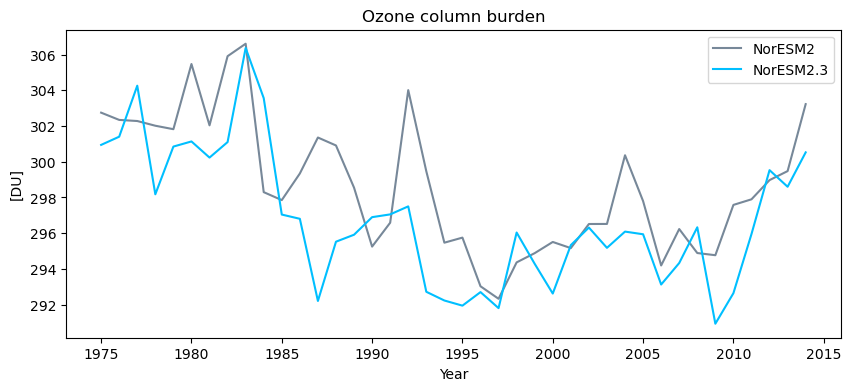

In [48]:
DU = 1.0 / 2.1415e-05
cb_O3 = "cb_O3"
o3_column = cb_o3[cb_O3].mean(dim=["lon", "lat"])
cb_o3_yearly_mean_glob = o3_column.groupby('time.year').mean(dim='time') * DU

cb_o3_column_KeyClim = cb_o3_KeyClim[cb_O3].mean(dim=["lon", "lat"])
cb_o3_yearly_mean_KeyClim_glob = cb_o3_column_KeyClim.groupby('time.year').mean(dim='time') * DU

plt.figure(figsize=(10, 4))
cb_o3_yearly_mean_KeyClim_glob.plot(color = "lightslategray", label = "NorESM2")
cb_o3_yearly_mean_glob.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[DU]")
plt.xlabel("Year")
plt.title("Ozone column burden")
plt.legend()
plt.show()

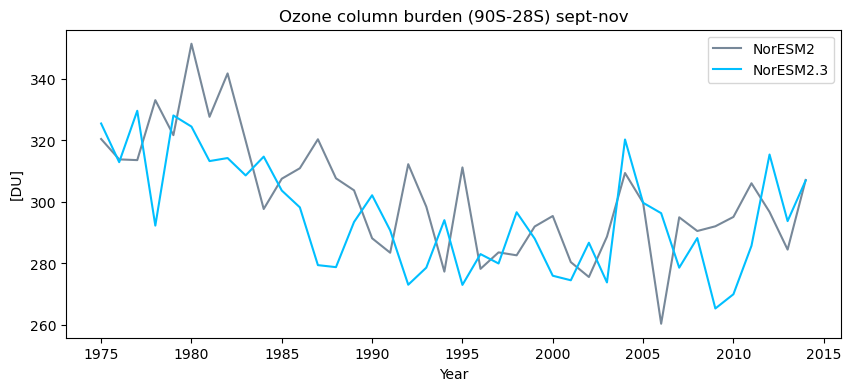

In [49]:
#  1DU = 2.1415e-05 kg/m2
DU = 1.0 / 2.1415e-05
o3_hole_months = [9, 10, 11]       # septober, october, november
o3_column = cb_o3[cb_O3].sel(lat = slice(-90, -28)).mean(dim=["lon", "lat"])
o3_column = o3_column.where(o3_column["time.month"].isin(o3_hole_months), drop=True)
o3_yearly_mean = o3_column.groupby('time.year').mean(dim='time') * DU

cb_o3_column_KeyClim = cb_o3_KeyClim[cb_O3].sel(lat = slice(-90, -28)).mean(dim=["lon", "lat"])
cb_o3_column_KeyClim = cb_o3_column_KeyClim.where(cb_o3_column_KeyClim["time.month"].isin(o3_hole_months), drop=True)
o3_yearly_mean_KeyClim = cb_o3_column_KeyClim.groupby('time.year').mean(dim='time') * DU

plt.figure(figsize=(10, 4))
o3_yearly_mean_KeyClim.plot(color = "lightslategray", label = "NorESM2")
o3_yearly_mean.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[DU]")
plt.xlabel("Year")
plt.title("Ozone column burden (90S-28S) sept-nov")
plt.legend()
plt.show()

In [50]:
ts_o3 = cb_o3["cb_O3"].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU
ts_o3_KeyClim = cb_o3_KeyClim["cb_O3"].weighted(weighted_lat_KeyClim).mean(dim=["lat", "lon"]) * DU

clim_o3 = ts_o3.groupby("time.month").mean("time")
clim_o3_KeyClim = ts_o3_KeyClim.groupby("time.month").mean("time")

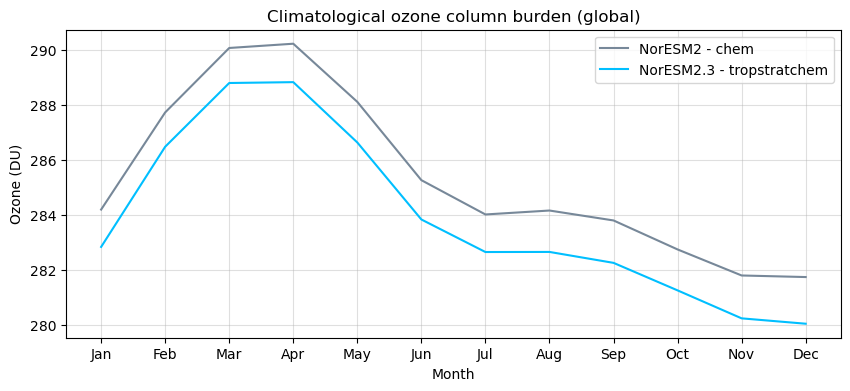

In [51]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


plt.figure(figsize=(10, 4))
plt.plot(months, clim_o3_KeyClim.values, color="lightslategray", label="NorESM2 - chem")
plt.plot(months, clim_o3.values, color="deepskyblue", label="NorESM2.3 - tropstratchem")
plt.ylabel("Ozone (DU)")
plt.xlabel("Month")
plt.grid(True, alpha=0.4)
plt.title("Climatological ozone column burden (global)")
plt.legend()
plt.show()

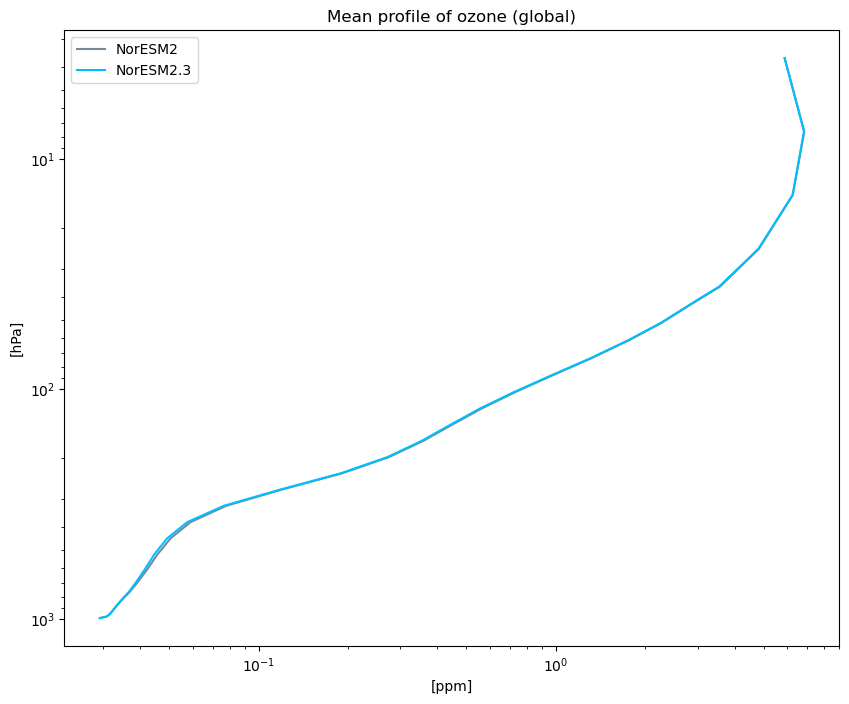

In [52]:
ppm_conversion_factor = 1e6  # 1 mol/mol = 1,000,000 ppm
O3 = "O3"
o3_profile = o3[O3].mean(dim=["lat", "lon", "time"])
o3_profile = o3_profile.transpose("lev")
o3_profile = o3_profile.values * ppm_conversion_factor

o3_profile_KeyClim = o3_KeyClim[O3].mean(dim=["lat", "lon", "time"])
o3_profile_KeyClim = o3_profile_KeyClim.transpose("lev")
o3_profile_KeyClim = o3_profile_KeyClim.values * ppm_conversion_factor

plt.figure(figsize=(10, 8))
plt.plot(o3_profile_KeyClim, o3_KeyClim["lev"], color = "lightslategray", label = "NorESM2")
plt.plot(o3_profile, o3["lev"], color = "deepskyblue", label = "NorESM2.3")
plt.yscale("log")
plt.xscale("log")
plt.gca().invert_yaxis()
plt.ylabel("[hPa]")
plt.xlabel("[ppm]")
plt.title("Mean profile of ozone (global)")
plt.legend()
plt.show()

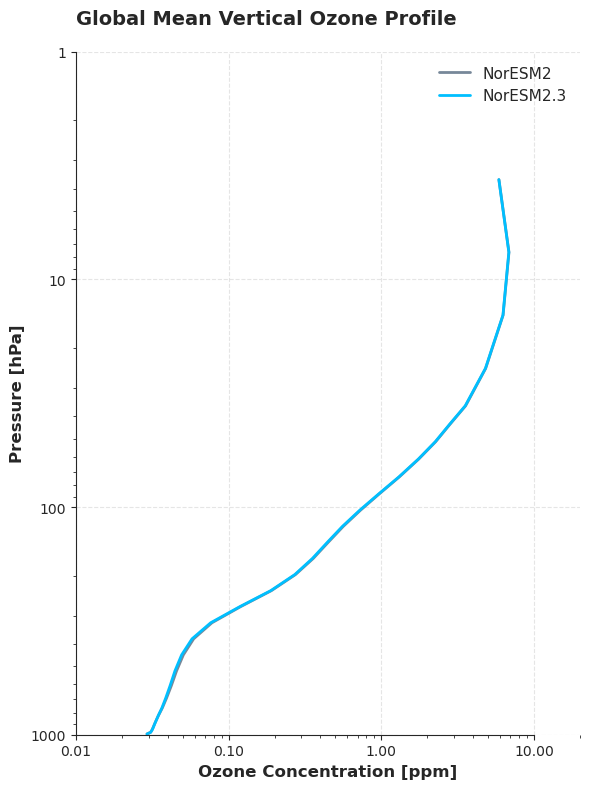

In [53]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_style("ticks")

plt.figure(figsize=(6, 8))

plt.plot(o3_profile_KeyClim, o3_KeyClim["lev"], 
         color="lightslategray", label="NorESM2", linewidth=2)
plt.plot(o3_profile, o3["lev"], 
         color="deepskyblue", label="NorESM2.3", linewidth=2)

plt.yscale("log")
plt.gca().invert_yaxis()
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(ticker.NullFormatter()) 
plt.ylim(1000, 1) 
plt.xscale("log")
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.xlim(0.01, 20) 

plt.grid(True, which="major", linestyle="--", alpha=0.5)

plt.ylabel("Pressure [hPa]", fontweight='bold', fontsize=12)
plt.xlabel("Ozone Concentration [ppm]", fontweight='bold', fontsize=12)
plt.title("Global Mean Vertical Ozone Profile", loc='left', fontsize=14, fontweight='bold', pad=20)

plt.legend(frameon=False, fontsize=11)

sns.despine(trim=True)

plt.tight_layout()
plt.show()

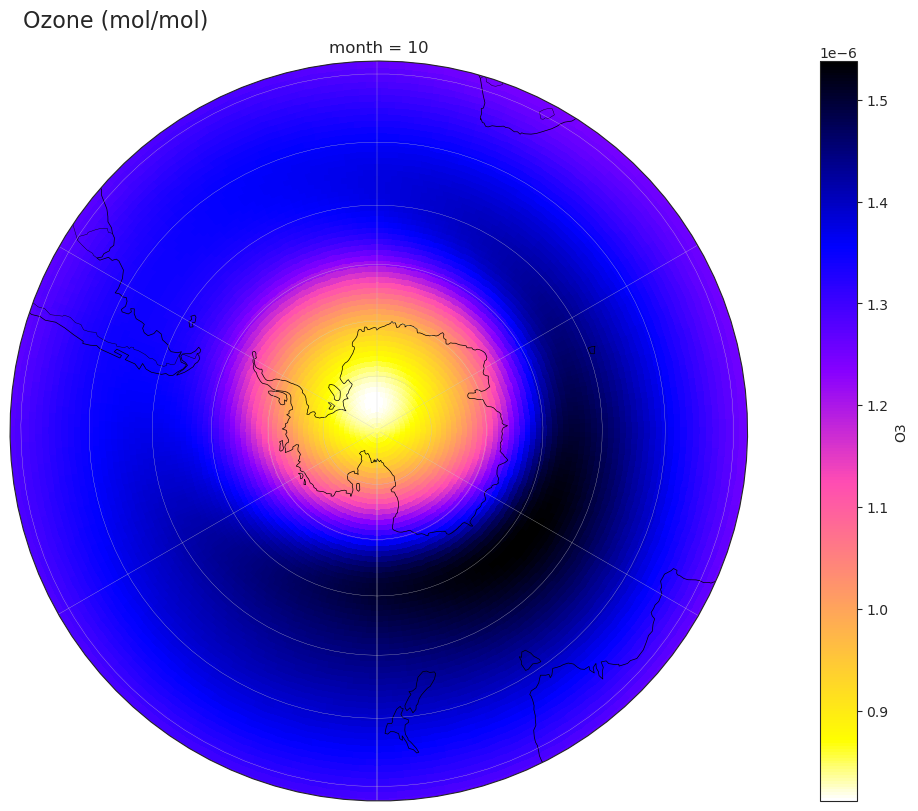

In [54]:
monthly = o3[O3].groupby("time.month").mean("time")
mean_o3 = monthly.mean(dim="lev")
fig, ax = plt.subplots(
    1, 1,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.SouthPolarStereo()},
    constrained_layout=True
)

polarCentral_set_latlim((-90, -28), ax)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=False, linewidth=0.2)

mean_o3[9].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="gnuplot2_r",
)

plt.suptitle("Ozone (mol/mol)", fontsize=16)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
plt.show()

## Radiation TOA

In [55]:
lw = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FLNT_h0_1975-2014.nc")
lw =lw.assign_coords(time=shifted_time)

In [56]:
lw_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/FLNT_h0_1975-2014.nc")

lw_KeyClim =lw_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(lw_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


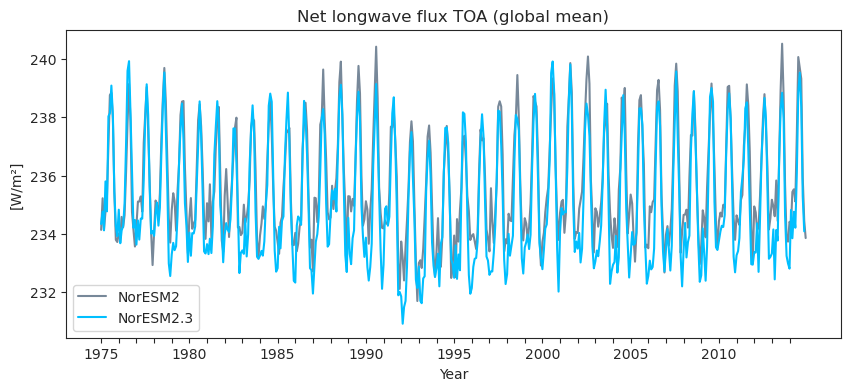

In [57]:
lw_toa = "FLNT"
lw_rad_toa = lw[lw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])
lw_rad_toa_KeyClim = lw_KeyClim[lw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
lw_rad_toa_KeyClim.plot(color="lightslategray", label = "NorESM2")
lw_rad_toa.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[W/m²]")
plt.title("Net longwave flux TOA (global mean)")
plt.legend()
plt.show()

In [58]:
sw = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FSNT_h0_1975-2014.nc")
sw =sw.assign_coords(time=shifted_time)

In [59]:
sw_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/FSNT_h0_1975-2014.nc")

sw_KeyClim =sw_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(sw_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


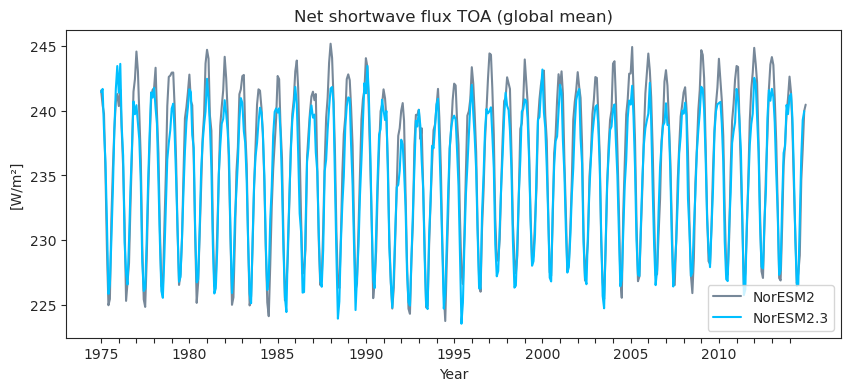

In [60]:
sw_toa = "FSNT"
sw_rad_toa = sw[sw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])
sw_rad_toa_KeyClim = sw_KeyClim[sw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
sw_rad_toa_KeyClim.plot(color="lightslategray", label = "NorESM2")
sw_rad_toa.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[W/m²]")
plt.title("Net shortwave flux TOA (global mean)")
plt.legend()
plt.show()

In [61]:
sol = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FSNTOA_h0_1975-2014.nc")
sol =sol.assign_coords(time=shifted_time)

In [62]:
sol_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/FSNTOA_h0_1975-2014.nc")

sol_KeyClim =sol_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(sol_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


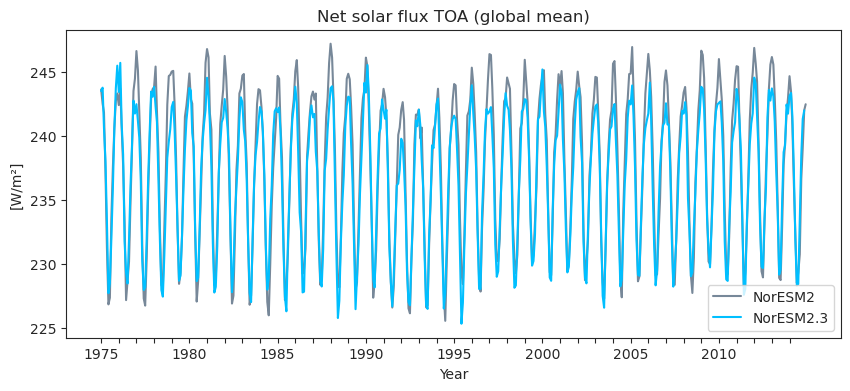

In [63]:
sw_toa = "FSNTOA"
sw_rad_toa = sol[sw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])
sw_rad_toa_KeyClim = sol_KeyClim[sw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
sw_rad_toa_KeyClim.plot(color = "lightslategray", label = "NorESM2")
sw_rad_toa.plot(color = "deepskyblue", label ="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[W/m²]")
plt.title("Net solar flux TOA (global mean)")
plt.legend()
plt.show()

## ENSO phase

In [64]:
ocn_frc = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/OCNFRAC_h0_1975-2014.nc")
tsurf= xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TS_h0_1975-2014.nc")

ocn_frc =ocn_frc.assign_coords(time=shifted_time)
tsurf =tsurf.assign_coords(time=shifted_time)


/tmp/ipykernel_550528/67183901.py:38: UserWarning: Adding colorbar to a different Figure <Figure size 1200x400 with 2 Axes> than <Figure size 1100x1300 with 8 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(pc, ax=ax, orientation="vertical", pad=0.02, aspect=20)


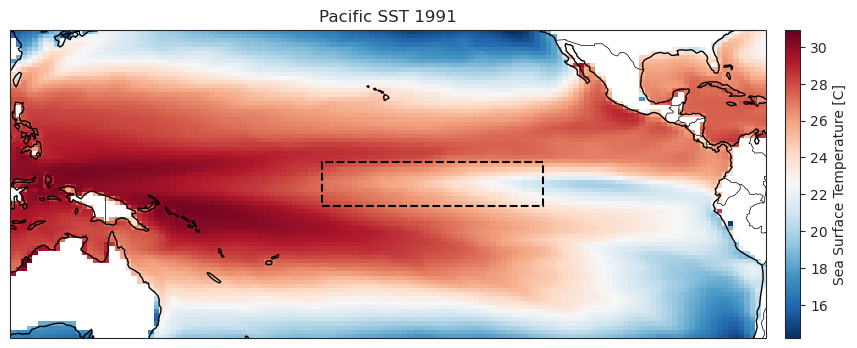

In [ ]:
ocn = "OCNFRAC"    # Ocean fraction
temp_s = "TS"      # surface temperature

temp_surf = tsurf[temp_s]  
ocean_frac = ocn_frc[ocn]

nino_lat_min, nino_lat_max = -5, 5
nino_lon_min, nino_lon_max = 190, 240

temp_surf_ocean = temp_surf.where(ocean_frac > 0)
sst_1991 = temp_surf_ocean.sel(time=slice("1991-01-01", "1991-12-01"))
baseline = temp_surf_ocean.groupby("time.month").mean("time")            # baseline =the whole dataset mean
sst_anom = sst_1991 - 273.15 #.groupby("time.month") - baseline

sst_anom_dec = sst_anom.mean(dim="time")
pacific = sst_anom_dec.sel(lon=slice(120, 290), lat =slice(-35, 35))

plt.figure(figsize=(12,4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

rect = Rectangle(
        (nino_lon_min, nino_lat_min),
        nino_lon_max - nino_lon_min,
        nino_lat_max - nino_lat_min,
        facecolor='none',
        edgecolor='black',
        linewidth=1.5,
        linestyle='--',
        transform=ccrs.PlateCarree()
    )

pc = pacific.plot(ax=ax, transform=ccrs.PlateCarree(),
             cmap="RdBu_r", add_colorbar=False)
ax.add_patch(rect)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Pacific SST 1991")
cbar = fig.colorbar(pc, ax=ax, orientation="vertical", pad=0.02, aspect=20)
cbar.set_label("Sea Surface Temperature [C]", fontsize=10)

plt.show()



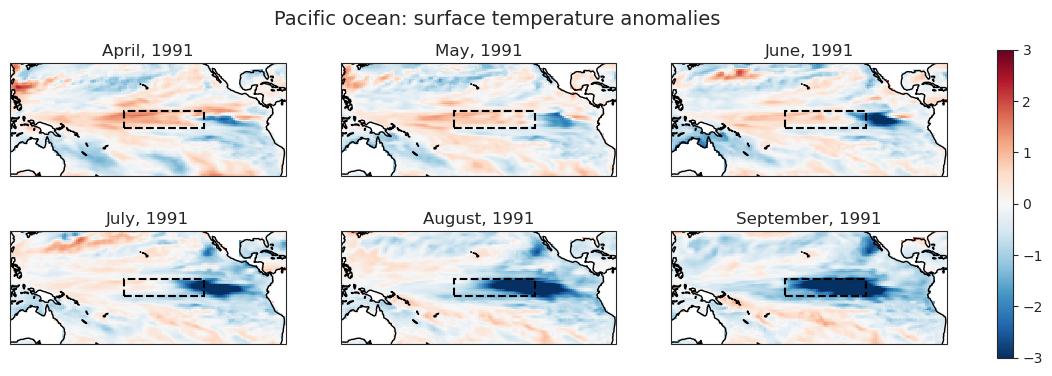

In [66]:
months_eruption = [4, 5, 6, 7, 8, 9] # april, may, june, july, august, september
nino_lat_min, nino_lat_max = -5, 5
nino_lon_min, nino_lon_max = 190, 240

fig, axes = plt.subplots(2, 3, figsize=(13, 4),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
    sharex=True, sharey=True
)
axes = axes.flatten()

for ax, month in zip(axes, months_eruption):
    sst_month = sst_anom.sel(time=sst_anom["time.month"] == month)
    sst_month_mean = sst_month.mean(dim="time")
    pacific_month = sst_month_mean.sel(lon=slice(120, 290), lat=slice(-35, 35))

    pcm = pacific_month.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=-3, vmax=3,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title(f"{calendar.month_name[month]}, 1991")

    rect = Rectangle(
        (nino_lon_min, nino_lat_min),
        nino_lon_max - nino_lon_min,
        nino_lat_max - nino_lat_min,
        facecolor='none',
        edgecolor='black',
        linewidth=1.5,
        linestyle='--',
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)


fig.suptitle("Pacific ocean: surface temperature anomalies", fontsize=14)
cbar = fig.colorbar(pcm, ax=axes, orientation="vertical", fraction=0.02)
plt.show()

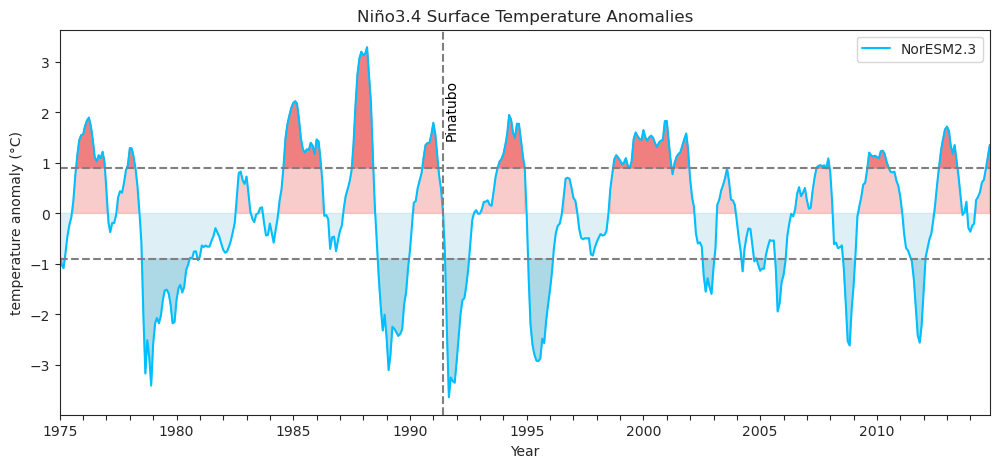

In [67]:
baseline = temp_surf_ocean.groupby("time.month").mean("time")
sst_anom = temp_surf_ocean.groupby("time.month") - baseline
sst_enso = sst_anom.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso = sst_enso.mean(dim=["lat", "lon"])

time = sst_enso["time"].values
values = sst_enso.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2.3")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

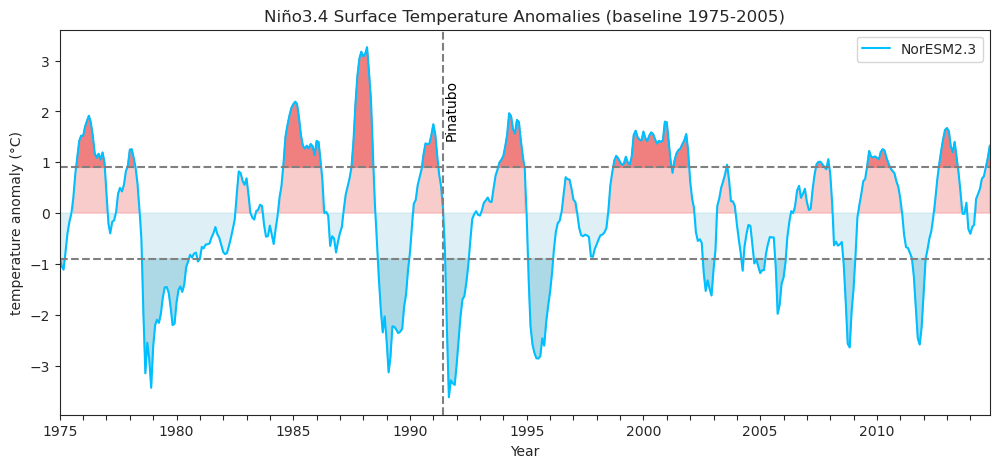

In [68]:
baseline = temp_surf_ocean.sel(time=slice("1975-01-01", "2005-01-01")).groupby("time.month").mean("time")
sst_anom = temp_surf_ocean.groupby("time.month") - baseline
sst_enso = sst_anom.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso = sst_enso.mean(dim=["lat", "lon"])

time = sst_enso["time"].values
values = sst_enso.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2.3")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies (baseline 1975-2005)")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

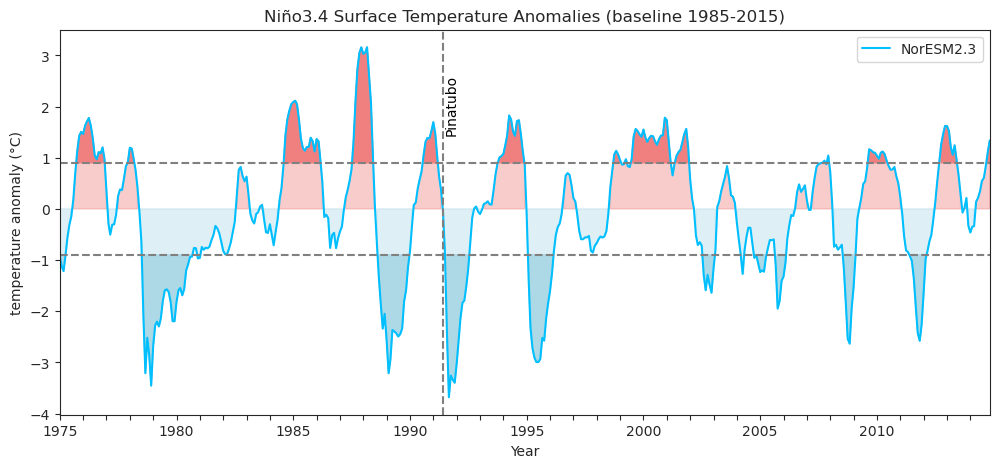

In [69]:
baseline = temp_surf_ocean.sel(time=slice("1985-01-01", "2014-12-01")).groupby("time.month").mean("time")
sst_anom = temp_surf_ocean.groupby("time.month") - baseline
sst_enso = sst_anom.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso = sst_enso.mean(dim=["lat", "lon"])

time = sst_enso["time"].values
values = sst_enso.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2.3")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies (baseline 1985-2015)")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

In [70]:
ocn_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/OCNFRAC_h0_1975-2014.nc")
tsurf_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/TS_h0_1975-2014.nc")

ocn_KeyClim =ocn_KeyClim.assign_coords(time=shifted_time_KeyClim)
tsurf_KeyClim =tsurf_KeyClim.assign_coords(time=shifted_time_KeyClim)


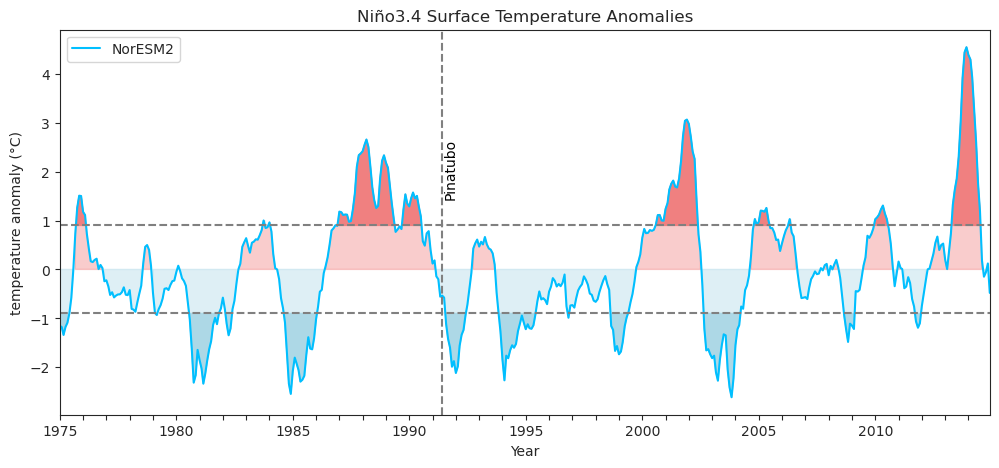

In [71]:
temp_surf_KeyClim = tsurf_KeyClim[temp_s]  
ocean_frac_KeyClim = ocn_KeyClim[ocn]

temp_surf_ocean_KeyClim = temp_surf_KeyClim.where(ocean_frac_KeyClim > 0)
base_KeyClim = temp_surf_ocean_KeyClim.groupby("time.month").mean("time")
sst_anom_KeyClim = temp_surf_ocean_KeyClim.groupby("time.month") - base_KeyClim
sst_enso_KeyClim = sst_anom_KeyClim.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso_KeyClim = sst_enso_KeyClim.mean(dim=["lat", "lon"])

time = sst_enso_KeyClim["time"].values
values = sst_enso_KeyClim.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

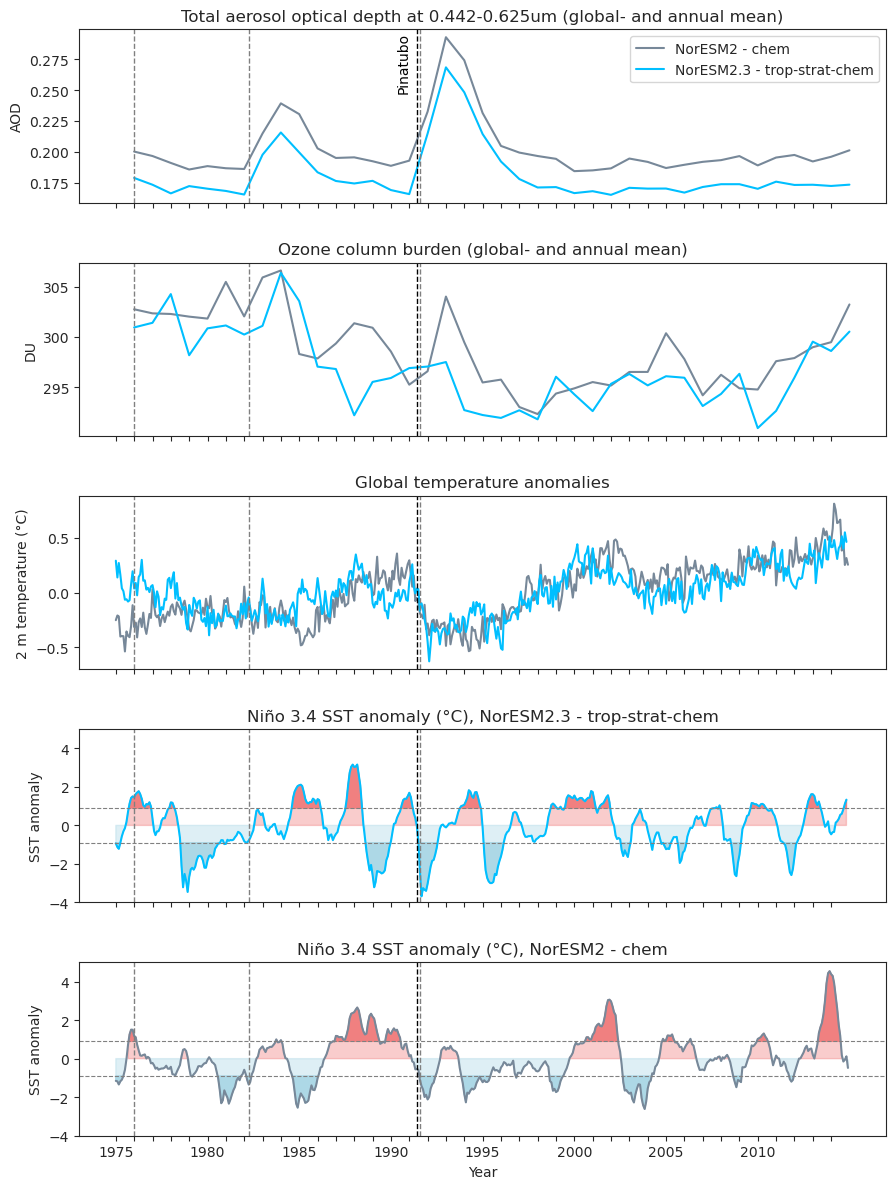

In [114]:
fig, (ax0, axo3, ax1, ax2, ax3) = plt.subplots(5, 1, figsize=(9, 12), sharex=True) #, height_ratios=[2, 1, 1])

ts_aod_KeyClim_year.plot(ax = ax0, color = "lightslategray", label = "NorESM2 - chem")
ts_aod_year.plot(ax=ax0, color = "deepskyblue", label = "NorESM2.3 - trop-strat-chem")

ax0.set_ylabel("AOD")
ax0.set_xlabel(" ")
ax0.set_title("Total aerosol optical depth at 0.442-0.625um (global- and annual mean)")
ax0.legend()

ax0.axvline(cftime.DatetimeNoLeap(1976, 1, 1), color="gray", linestyle="--", lw=1)
ax0.axvline(cftime.DatetimeNoLeap(1982, 4, 1), color="gray", linestyle="--", lw=1)
ax0.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color="k", linestyle="--", lw=1)
ax0.axvline(cftime.DatetimeNoLeap(1991, 8, 1), color="gray", linestyle="--", lw=1)
ax0.text(cftime.DatetimeNoLeap(1990, 5, 1), 0.25, "Pinatubo", rotation=90, color="k")

time_axis = ts_aod_year.time.values
time_axis_keyclim = ts_aod_KeyClim_year.time.values

axo3.plot(time_axis_keyclim, cb_o3_yearly_mean_KeyClim_glob.values, 
          color="lightslategray", label="NorESM2 - chem")

axo3.plot(time_axis, cb_o3_yearly_mean_glob.values, 
          color="deepskyblue", label="NorESM2.3 - trop-strat-chem")

axo3.set_ylabel("DU")
axo3.set_xlabel(" ")
axo3.set_title("Ozone column burden (global- and annual mean)")

axo3.axvline(cftime.DatetimeNoLeap(1976, 1, 1), color="gray", linestyle="--", lw=1)
axo3.axvline(cftime.DatetimeNoLeap(1982, 4, 1), color="gray", linestyle="--", lw=1)
axo3.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color="k", linestyle="--", lw=1)
axo3.axvline(cftime.DatetimeNoLeap(1991, 8, 1), color="gray", linestyle="--", lw=1)

ts_KeyClim_anom.plot(ax=ax1, color="lightslategray")
ts_anom.plot(ax=ax1, color="deepskyblue")

ax1.set_ylabel("2 m temperature (°C)")
ax1.set_xlabel(" ")
ax1.set_title("Global temperature anomalies")

ax1.axvline(cftime.DatetimeNoLeap(1976, 1, 1), color="gray", linestyle="--", lw=1)
ax1.axvline(cftime.DatetimeNoLeap(1982, 4, 1), color="gray", linestyle="--", lw=1)
ax1.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color="k", linestyle="--", lw=1)
ax1.axvline(cftime.DatetimeNoLeap(1991, 8, 1), color="gray", linestyle="--", lw=1)

time = sst_enso["time"].values
values = sst_enso.values

ax2.plot(time, values, color="deepskyblue", label="NorESM2.3 - trop-strat-chem")
ax2.fill_between(time, 0, values, where=values >= 0, color="lightcoral", alpha=0.4)
ax2.fill_between(time, 0, values, where=values <= 0, color="lightblue", alpha=0.4)
ax2.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
ax2.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

ax2.axhline(threshold, color="gray", linestyle="--", lw=0.8)
ax2.axhline(-threshold, color="gray", linestyle="--", lw=0.8)
ax2.axvline(cftime.DatetimeNoLeap(1976, 1, 1), color="gray", linestyle="--", lw=1)
ax2.axvline(cftime.DatetimeNoLeap(1982, 4, 1), color="gray", linestyle="--", lw=1)
ax2.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color="k", linestyle="--", lw=1)
ax2.axvline(cftime.DatetimeNoLeap(1991, 8, 1), color="gray", linestyle="--", lw=1)

ax2.set_title("Niño 3.4 SST anomaly (°C), NorESM2.3 - trop-strat-chem")
ax2.set_ylabel("SST anomaly")
ax2.set_ylim(-4, 5)
ax2.set_xlabel(" ")

time_KeyClim = sst_enso_KeyClim["time"].values
values_KeyClim = sst_enso_KeyClim.values

ax3.plot(time_KeyClim, values_KeyClim, color="lightslategray", label="NorESM2 - chem")
ax3.fill_between(time_KeyClim, 0, values_KeyClim, where=values_KeyClim >= 0, color="lightcoral", alpha=0.4)
ax3.fill_between(time_KeyClim, 0, values_KeyClim, where=values_KeyClim <= 0, color="lightblue", alpha=0.4)
ax3.fill_between(
    time_KeyClim, threshold, values_KeyClim,
    where=values_KeyClim >= threshold,
    color="lightcoral"
)
ax3.fill_between(
    time_KeyClim, -threshold, values_KeyClim,
    where=values_KeyClim <= -threshold,
    color="lightblue"
)

ax3.axhline(threshold, color="gray", linestyle="--", lw=0.8)
ax3.axhline(-threshold, color="gray", linestyle="--", lw=0.8)
ax3.axvline(cftime.DatetimeNoLeap(1976, 1, 1), color="gray", linestyle="--", lw=1)
ax3.axvline(cftime.DatetimeNoLeap(1982, 4, 1), color="gray", linestyle="--", lw=1)
ax3.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color="k", linestyle="--", lw=1)
ax3.axvline(cftime.DatetimeNoLeap(1991, 8, 1), color="gray", linestyle="--", lw=1)

ax3.set_title("Niño 3.4 SST anomaly (°C), NorESM2 - chem")
ax3.set_ylabel("SST anomaly")
ax3.set_ylim(-4, 5)
ax3.set_xlabel("Year")

years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax3.set_xticks(year_ticks)
ax3.set_xticklabels([str(y) if y % 5 == 0 else "" for y in years])

plt.tight_layout()
plt.show()


## Precipitation

In [73]:
conv = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/PRECC_h0_1975-2014.nc")
large_scale = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/PRECL_h0_1975-2014.nc")

conv =conv.assign_coords(time=shifted_time)
large_scale =large_scale.assign_coords(time=shifted_time)

In [74]:
conv_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/PRECC_h0_1975-2014.nc")
large_scale_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/PRECL_h0_1975-2014.nc")

conv_KeyClim =conv_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(conv_KeyClim["time"].values[:5])

large_scale_KeyClim =large_scale_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(large_scale_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


In [75]:
conv

<xarray.Dataset> Size: 106MB
Dimensions:    (lat: 192, lon: 288, time: 478, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 4kB 1975-01-01 00:00:00 ... 2014-11-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    time_bnds  (time, nbnd) object 8kB ...
    PRECC      (time, lat, lon) float32 106MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              NHIST_tropstratchem_f09_tn14_20250917_1975_2014
    logname:           elihho
    host:              
    initial_file:      NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03....
    topography_file:   /cluster/shared/noresm/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1
    history:           Fri Mar  6 13:42:53 2026: ncrcat -O -v PRECC /nird/dat...
    NCO:               netCDF Operators version 5.3.0 (Homepage = http://nco....

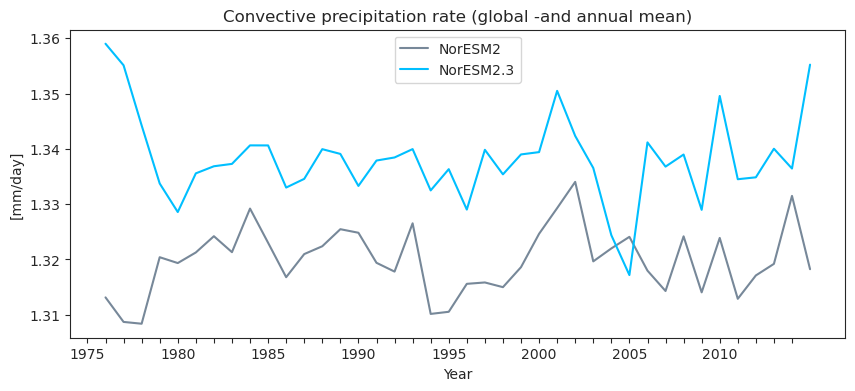

In [76]:
convective = "PRECC"
large_scale_var = "PRECL"

conv_prec = conv[convective].weighted(weighted_lat).mean(dim=["lat", "lon"])
conv_prec_year = conv_prec.resample(time="1YE").mean(dim="time") *60*60*24 *1000
conv_prec_KeyClim = conv_KeyClim[convective].weighted(weighted_lat).mean(dim=["lat", "lon"])
conv_prec_year_KeyClim = conv_prec_KeyClim.resample(time="1YE").mean(dim="time") *60*60*24 *1000

plt.figure(figsize=(10, 4))
conv_prec_year_KeyClim.plot(color = "lightslategray", label = "NorESM2")
conv_prec_year.plot(color = "deepskyblue", label ="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[mm/day]")
plt.title("Convective precipitation rate (global -and annual mean)")
plt.legend()
plt.show()

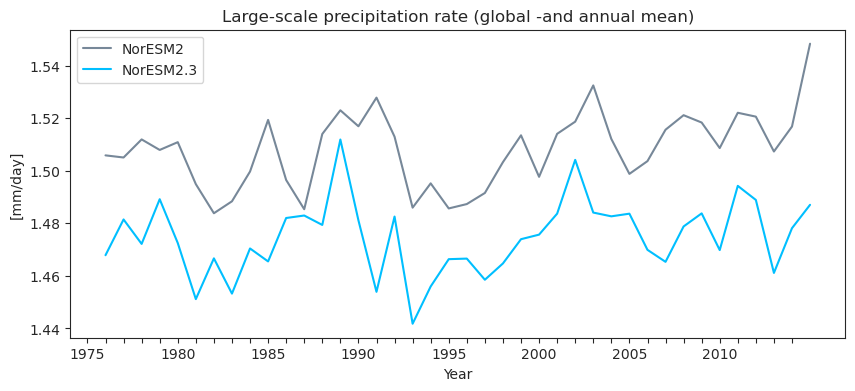

In [77]:
large_scale_prec = large_scale[large_scale_var].weighted(weighted_lat).mean(dim=["lat", "lon"])
large_scale_prec_year = large_scale_prec.resample(time="1YE").mean(dim="time") *60*60*24 *1000
large_scale_prec_KeyClim = large_scale_KeyClim[large_scale_var].weighted(weighted_lat).mean(dim=["lat", "lon"])
large_scale_prec_year_KeyClim = large_scale_prec_KeyClim.resample(time="1YE").mean(dim="time") *60*60*24*1000

plt.figure(figsize=(10, 4))
large_scale_prec_year_KeyClim.plot(color = "lightslategray", label = "NorESM2")
large_scale_prec_year.plot(color = "deepskyblue", label ="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[mm/day]")
plt.title("Large-scale precipitation rate (global -and annual mean)")
plt.legend()
plt.show()


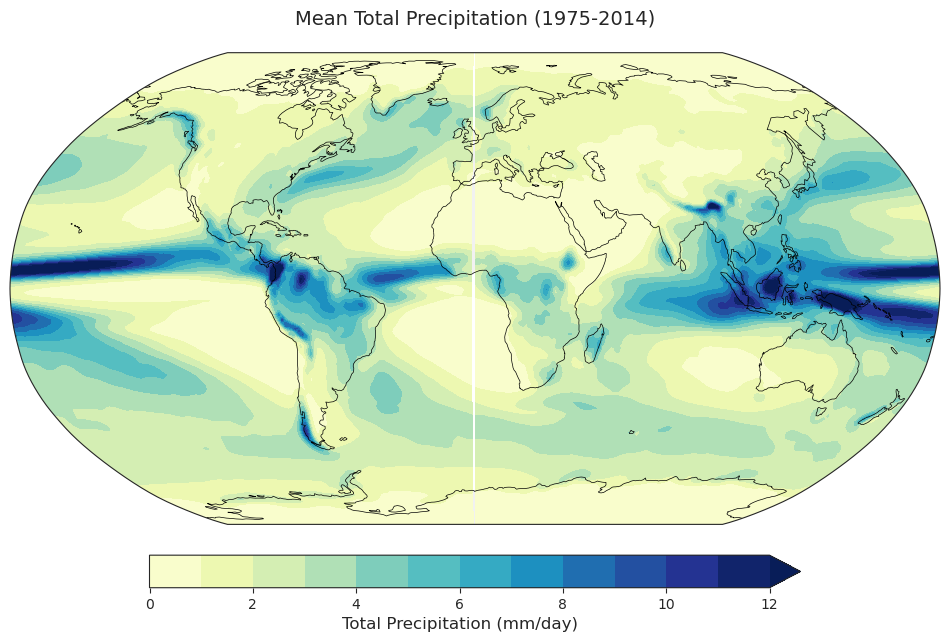

In [78]:
total_precip = (conv['PRECC'] + large_scale['PRECL']).mean(dim='time')
total_precip_mm = total_precip * 86400 * 1000

max_val = 12 
levels = np.linspace(0, max_val, 13) 

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

ax.coastlines(resolution='110m', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

cf = ax.contourf(
    total_precip_mm.lon, total_precip_mm.lat, total_precip_mm.values,
    transform=ccrs.PlateCarree(),
    levels=levels,
    cmap='YlGnBu',
    extend='max'
)

cbar = fig.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Total Precipitation (mm/day)', fontsize=12)

plt.title("Mean Total Precipitation (1975-2014)", fontsize=14, pad=20)

ax.set_global()

plt.show()

## OH at different levels

In [79]:
oh = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/OH_h0_1975-2014.nc")
oh =oh.assign_coords(time=shifted_time)

In [80]:
oh_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/OH_h0_1975-2014.nc")
oh_KeyClim =oh_KeyClim.assign_coords(time=shifted_time_KeyClim)

In [81]:
oh_surface = oh["OH"].isel(lev=-1).weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_10km = oh["OH"].sel(lev=265, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_20km = oh["OH"].sel(lev=64.7, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_25km = oh["OH"].sel(lev=54.7, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])

oh_surface_KeyClim = oh_KeyClim["OH"].isel(lev=-1).weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_10km_KeyClim = oh_KeyClim["OH"].sel(lev=265, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_20km_KeyClim = oh_KeyClim["OH"].sel(lev=64.7, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_25km_KeyClim = oh_KeyClim["OH"].sel(lev=54.7, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])

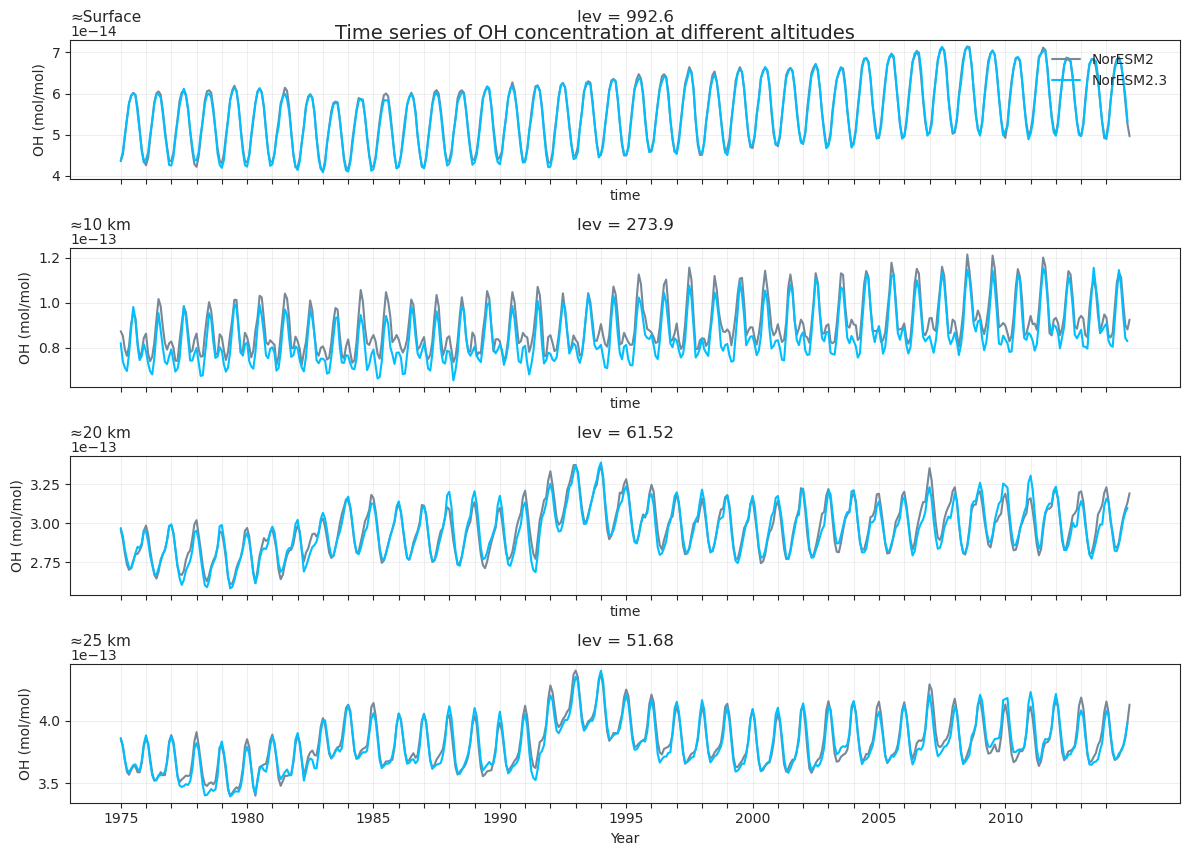

In [82]:
fig, ax = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

labels = ["≈Surface", "≈10 km", "≈20 km", "≈25 km"]
series = [oh_surface, oh_10km, oh_20km, oh_25km]
series_keyclim = [oh_surface_KeyClim, oh_10km_KeyClim, oh_20km_KeyClim, oh_25km_KeyClim]

for i, (noresm, keyclim, label) in enumerate(zip(series, series_keyclim, labels)):
    keyclim.plot(ax=ax[i], color="lightslategray", label="NorESM2")
    noresm.plot(ax=ax[i], color="deepskyblue", label="NorESM2.3")

    ax[i].set_ylabel("OH (mol/mol)")
    ax[i].set_title(label, loc="left", fontsize=11, pad=2)
    ax[i].grid(alpha=0.3)
    if i == 0:
        ax[i].legend(frameon=False, loc="upper right")

years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax[-1].set_xticks(year_ticks)
ax[-1].set_xticklabels([str(y) if y % 5 == 0 else "" for y in years])
ax[-1].set_xlabel("Year")

plt.suptitle("Time series of OH concentration at different altitudes", fontsize=14, y=0.93)
plt.tight_layout()
plt.show()

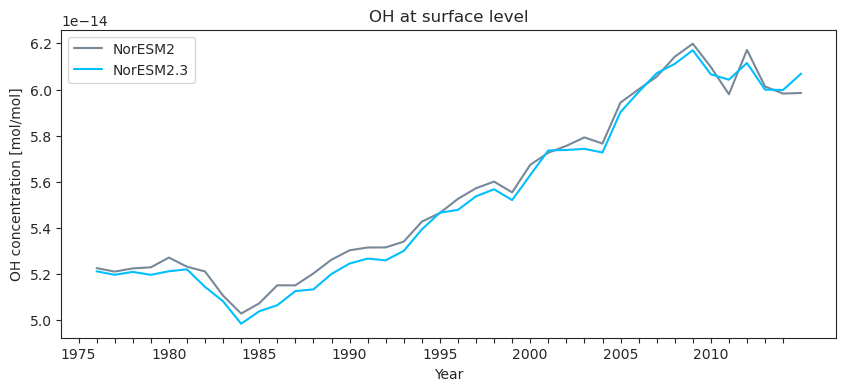

In [83]:
oh_surf_year = oh_surface.resample(time="1YE").mean(dim="time")
oh_surf_year_KeyClim = oh_surface_KeyClim.resample(time="1YE").mean(dim="time")

plt.figure(figsize=(10, 4))
oh_surf_year_KeyClim.plot(color="lightslategray", label="NorESM2")
oh_surf_year.plot(color="deepskyblue", label="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("OH concentration [mol/mol]")
plt.xlabel("Year")
plt.title("OH at surface level")
plt.legend()
plt.show()


In [84]:
so2 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/SO2_SRF_h0_1975-2014.nc")
so2= so2.assign_coords(time=shifted_time)
so2_surf = so2["SO2_SRF"].weighted(weighted_lat).mean(dim=["lat", "lon"])

so2_KeyClim = xr.open_dataset("/nird/datapeak/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/SO2_SRF_h0_1975-2014.nc")
so2_KeyClim = so2_KeyClim.assign_coords(time=shifted_time_KeyClim)
so2_surf_KeyClim = so2_KeyClim["SO2_SRF"].weighted(weighted_lat).mean(dim=["lat", "lon"])

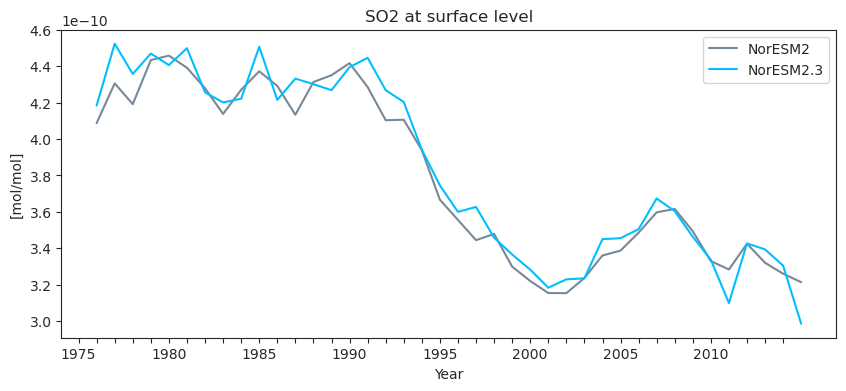

In [85]:
so2_surf = so2_surf.resample(time="1YE").mean(dim="time")
so2_surf_KeyClim = so2_surf_KeyClim.resample(time="1YE").mean(dim="time")

plt.figure(figsize=(10, 4))
so2_surf_KeyClim.plot(color="lightslategray", label="NorESM2")
so2_surf.plot(color="deepskyblue", label="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("[mol/mol]")
plt.xlabel("Year")
plt.title("SO2 at surface level")
plt.legend()
plt.show()

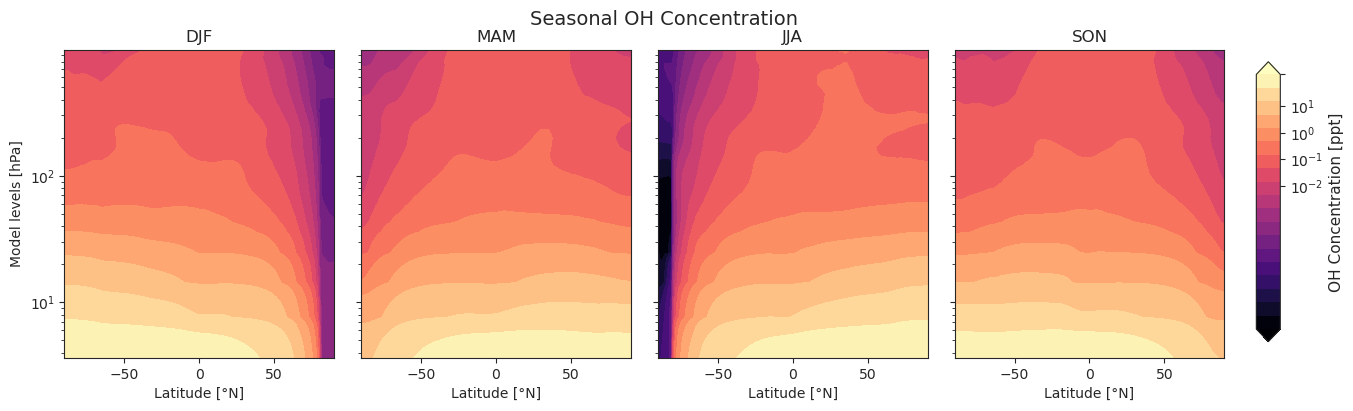

In [117]:
oh_seasonal = oh["OH"].groupby("time.season").mean(dim=["time", "lon"])
oh_seasonal = oh_seasonal * 1e12

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
axes = axes.flatten()
seasons = ["DJF", "MAM", "JJA", "SON"]

v_min_val = float(oh_seasonal.where(oh_seasonal > 0).min().values)
v_max_val = float(oh_seasonal.max().values)

if np.isnan(v_min_val) or v_min_val <= 0:
    v_min_val = v_max_val * 1e-6

levs = np.logspace(np.log10(v_min_val), np.log10(v_max_val), 20)

for i, season in enumerate(seasons):
    ax = axes[i]
    data = oh_seasonal.sel(season=season)
    
    im = ax.contourf(
        oh_seasonal.lat.values, 
        oh_seasonal.lev.values, 
        data.values, 
        levels=levs,
        norm=colors.LogNorm(vmin=v_min_val, vmax=v_max_val),
        cmap="magma",
        extend='both'
    )
    
    ax.set_yscale('log')
    ax.invert_yaxis() 
    ax.set_title(f"{season}", fontsize=12)
    ax.set_ylabel("")
    
    ax.grid(True, which="major", ls=":", color='gray', alpha=0.5)

fig.subplots_adjust(right=0.85, hspace=0.2, wspace=0.1)
cbar_ax = fig.add_axes([0.87, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)

cbar.ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

cbar.set_ticks([0.01, 0.1, 1, 10, v_max_val])

cbar.set_label('OH Concentration [ppt]', fontsize=11)

axes[0].set_ylabel("Model levels [hPa]")
axes[0].set_xlabel("Latitude [°N]")
axes[1].set_xlabel("Latitude [°N]")
axes[2].set_xlabel("Latitude [°N]")
axes[3].set_xlabel("Latitude [°N]")

plt.suptitle("Seasonal OH Concentration", fontsize=14)
plt.show()